In [1]:
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from collections import defaultdict
from sklearn.metrics import precision_recall_curve

In [2]:
def analyze_full_log(log_file_path: str):
    """
    1534개 쿼리가 담긴 전체 로그 파일을 파싱하여 
    실험 이름을 추출하고, 모듈별 평균 실행 시간과 전체 노드 스코어 분포를 시각화합니다.
    """
    print(f"🔍 Analyzing log file: {log_file_path}")
    
    with open(log_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        full_text = "".join(lines)

    # ==========================================
    # 0. Experiment Name 파싱 (새로 추가된 로직)
    # ==========================================
    exp_name_match = re.search(r'Starting Evaluation for Experiment: \[(.*?)\]', full_text)
    experiment_name = exp_name_match.group(1) if exp_name_match else "Unknown_Experiment"
    print(f"🔬 Detected Experiment: {experiment_name}")

    # ==========================================
    # 1. Node Scores 파싱 
    # ==========================================
    score_matches = re.findall(r'node_scores:\s*tensor\(\[(.*?)\]\)', full_text, re.DOTALL)
    
    all_scores = []
    for match in score_matches:
        cleaned_str = match.replace('\n', ' ')
        scores = [float(s.strip()) for s in cleaned_str.split(',') if s.strip()]
        all_scores.extend(scores)
        
    print(f"✅ Extracted {len(all_scores)} node scores across all queries.")

    # ==========================================
    # 2. 모듈별 실행 시간 파싱
    # ==========================================
    time_format = "%Y-%m-%d %H:%M:%S"
    durations = defaultdict(list)
    current_starts = {}

    markers = {
        "Graph Build": {"start": "Building Graph", "end": "Graph Build Completed."},
        "NLQ Encoding": {"start": "Encoding NLQ", "end": "Encoding NLQ Completed."},
        "Seed Selection": {"start": "Selecting Seed Nodes", "end": "Seed Nodes Selected"},
        "Subgraph Extraction": {"start": "Subgraph Extracting", "end": "Subgraph Extracted"},
        "Agent Filtering": {"start": "Agent Filtering", "end": "Agent Filtered"},
        "SQL Generation": {"start": "SQL Generation", "end": "Generated SQL:"}
    }

    ts_regex = re.compile(r'^\[(.*?)\]')

    for line in lines:
        ts_match = ts_regex.search(line)
        if not ts_match:
            continue
        
        ts_str = ts_match.group(1)
        try:
            ts = datetime.strptime(ts_str, time_format)
        except ValueError:
            continue
            
        for module, events in markers.items():
            if events["start"] in line:
                current_starts[module] = ts
            elif events["end"] in line and module in current_starts:
                duration = (ts - current_starts[module]).total_seconds()
                durations[module].append(duration)
                del current_starts[module]

    avg_durations = {mod: np.mean(durs) if durs else 0.0 for mod, durs in durations.items()}
    
    for mod, avg_t in avg_durations.items():
        print(f"⏱️ Average time for [{mod}]: {avg_t:.3f} seconds (over {len(durations[mod])} queries)")

    # ==========================================
    # 3. 데이터 시각화 (Visualization)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 💡 캔버스 전체를 아우르는 메인 타이틀에 실험 이름 삽입
    fig.suptitle(f"Pipeline Analysis Report: {experiment_name}", fontsize=18, fontweight='bold', y=1.02)

    # [Plot 1] 전체 노드 스코어 분포 (Histogram)
    if all_scores:
        axes[0].hist(all_scores, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
        axes[0].axvline(np.mean(all_scores), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_scores):.3f}')
        axes[0].set_title(f'Node Scores Distribution', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].legend()

    # [Plot 2] 모듈별 평균 실행 시간 (Bar Chart)
    if avg_durations:
        modules = list(avg_durations.keys())
        times = list(avg_durations.values())
        
        axes[1].barh(modules[::-1], times[::-1], color='coral', edgecolor='black')
        axes[1].set_title(f'Average Execution Time per Module', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Average Time (seconds)', fontsize=12)
        
        for i, v in enumerate(times[::-1]):
            axes[1].text(v + (max(times)*0.02), i, f"{v:.2f}s", va='center', fontweight='bold')

    plt.tight_layout()
    # 💡 저장되는 파일명에도 실험 이름을 포함시켜 관리를 용이하게 함
    # save_path = f"pipeline_analysis_{experiment_name}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"📊 Visualization saved to: {save_path}")
    plt.show()

In [3]:
def plot_global_analysis(json_path: str, exp_name: str, max_k: int = 50):
    # 1. 데이터 로드
    print(f"Loading data from {json_path}...")
    with open(json_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f if line.strip()]
    df = pd.DataFrame(data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Global Schema Linking Performance: {exp_name}", fontsize=18, fontweight='bold', y=1.05)

    # ==========================================
    # Plot 1: Global Violin Plot (Separability)
    # ==========================================
    # 바이올린 플롯으로 두 클래스(Noise vs Gold)의 점수 분포와 밀도를 시각화
    sns.violinplot(data=df, x='is_gold', y='score', 
                   palette={True: '#1f77b4', False: '#d62728',
                            'True': '#1f77b4', 'False': '#d62728'}, 
                   inner='quartile', ax=axes[0])
    
    axes[0].set_title("Global Node Score Distribution", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Is Gold Schema? (True=Positive, False=Noise)", fontsize=12)
    axes[0].set_ylabel("Predicted Score (Cosine Similarity)", fontsize=12)
    axes[0].set_xticklabels(['False (Noise)', 'True (Gold)'])

    # ==========================================
    # Plot 2: Recall@K Curve (Retrieval Performance)
    # ==========================================
    print("Calculating Recall@K across all queries...")
    
    # 쿼리별로 그룹화하여 계산
    recall_at_k_list = {k: [] for k in range(1, max_k + 1)}
    
    grouped = df.groupby('query_id')
    for query_id, group in grouped:
        # 점수 내림차순 정렬
        sorted_group = group.sort_values(by='score', ascending=False).reset_index(drop=True)
        total_golds = sorted_group['is_gold'].sum()
        
        # Gold 노드가 아예 없는 예외적 쿼리는 스킵
        if total_golds == 0:
            continue
            
        # 1부터 max_k까지 Recall 계산
        for k in range(1, max_k + 1):
            hits_in_top_k = sorted_group.head(k)['is_gold'].sum()
            recall = hits_in_top_k / total_golds
            recall_at_k_list[k].append(recall)

    # 전체 쿼리에 대한 평균 Recall@K 산출
    k_values = list(range(1, max_k + 1))
    mean_recalls = [np.mean(recall_at_k_list[k]) * 100 for k in k_values]

    # 라인 플롯 그리기
    axes[1].plot(k_values, mean_recalls, marker='o', markersize=4, linestyle='-', color='#2ca02c', linewidth=2)
    axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.7)
    
    axes[1].set_title(f"Average Recall@K Curve (Up to Top-{max_k})", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("K (Number of Retrieved Nodes)", fontsize=12)
    axes[1].set_ylabel("Recall (%)", fontsize=12)
    axes[1].set_ylim(0, 105)
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # 텍스트 주석 (Top-10, Top-20 등 주요 지점 수치 표기)
    for k_idx in [5, 10, 20, 50]:
        if k_idx <= max_k:
            axes[1].annotate(f"{mean_recalls[k_idx-1]:.1f}%", 
                             (k_idx, mean_recalls[k_idx-1]), 
                             textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

    plt.tight_layout()
    # save_path = f"global_performance_{exp_name}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"📊 Visualization saved to: {save_path}")
    plt.show()

In [4]:
def plot_threshold_tuning(json_path: str, exp_name: str):
    print(f"Loading data from {json_path}...")
    with open(json_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f if line.strip()]
    df = pd.DataFrame(data)

    # 1. Scikit-learn을 이용한 모든 임계값에서의 P, R 계산
    y_true = df['is_gold'].astype(int)
    y_scores = df['score']
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    
    # thresholds 배열의 길이가 P, R보다 1 작으므로 맞춰줍니다.
    precisions = precisions[:-1]
    recalls = recalls[:-1]
    
    # 2. F1-Score 계산 및 최적의 Threshold 탐색
    # 분모가 0이 되는 것을 방지하기 위해 1e-10 추가
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_p = precisions[best_idx]
    best_r = recalls[best_idx]

    print(f"🎯 [Optimal Threshold Found]")
    print(f"  - Threshold: {best_threshold:.4f}")
    print(f"  - F1-Score:  {best_f1:.4f}")
    print(f"  - Precision: {best_p:.4f} / Recall: {best_r:.4f}")

    # ==========================================
    # 시각화 (Visualization)
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Threshold Tuning Analysis: {exp_name}", fontsize=18, fontweight='bold', y=1.05)

    # [Plot 1] Threshold vs Metrics Curve
    axes[0].plot(thresholds, precisions, label='Precision', color='#1f77b4', linewidth=2)
    axes[0].plot(thresholds, recalls, label='Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(thresholds, f1_scores, label='F1-Score', color='#2ca02c', linewidth=3, linestyle='--')
    
    # 최적 임계값에 수직선 표시
    axes[0].axvline(x=best_threshold, color='red', linestyle=':', linewidth=2)
    axes[0].scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
    axes[0].annotate(f'Best Thresh: {best_threshold:.3f}\n(F1: {best_f1:.3f})', 
                     (best_threshold, best_f1), textcoords="offset points", xytext=(10,-15), ha='left', fontsize=11, color='red', fontweight='bold')

    axes[0].set_title("Metrics vs. Threshold", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Node Score Threshold", fontsize=12)
    axes[0].set_ylabel("Score (0.0 ~ 1.0)", fontsize=12)
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # [Plot 2] Precision-Recall Curve
    axes[1].plot(recalls, precisions, color='purple', linewidth=2)
    
    # 최적 지점(Best F1) 마킹
    axes[1].scatter([best_r], [best_p], color='red', s=100, zorder=5, label=f'Best Threshold ({best_threshold:.3f})')
    
    axes[1].set_title("Precision-Recall (PR) Curve", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Recall", fontsize=12)
    axes[1].set_ylabel("Precision", fontsize=12)
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    # save_path = f"threshold_tuning_{exp_name}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"📊 Visualization saved to: {save_path}")
    plt.show()

In [5]:
def plot_dashboard(score_json_path: str, profiling_json_path: str, exp_name: str, max_k: int = 50):
    print(f"🔍 Loading Score data from {score_json_path}...")
    print(f"🔍 Loading Profiling data from {profiling_json_path}...")
    
    # ==========================================
    # 1. 데이터 로드
    # ==========================================
    with open(score_json_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f if line.strip()]
        df = pd.DataFrame(data)

    with open(profiling_json_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f if line.strip()]
        prof_df = pd.DataFrame(data)
    
    time_cols = [c for c in prof_df.columns if c != 'query_id']
    avg_durations = prof_df[time_cols].mean().to_dict()
    total_avg_time = sum(avg_durations.values())

    # ==========================================
    # 2. Figure Layout 설정 (4x2 Grid)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(4, 2, figsize=(18, 24))
    fig.suptitle(f"Schema Linking Dashboard: {exp_name}", fontsize=24, fontweight='bold', y=1.02)

    # --------------------------------------------------
    # [Panel 1] 실행 시간 (Execution Time)
    # --------------------------------------------------
    if avg_durations:
        sorted_modules = sorted(avg_durations.keys())
        times = [avg_durations[m] for m in sorted_modules]
        axes[0, 0].barh(sorted_modules[::-1], times[::-1], color='coral', edgecolor='black', alpha=0.8)
        axes[0, 0].set_title("1. Execution Time per Module", fontsize=15, fontweight='bold')
        axes[0, 0].set_xlabel("Average Time (seconds)", fontsize=12)
        for i, v in enumerate(times[::-1]):
            axes[0, 0].text(v + (max(times)*0.02 if max(times)>0 else 0.05), i, f"{v:.3f}s", va='center', fontweight='bold')

    # --------------------------------------------------
    # [Panel 2] 전체 노드 스코어 분포 (Histogram)
    # --------------------------------------------------
    all_scores = df['score'].values
    axes[0, 1].hist(all_scores, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(np.mean(all_scores), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(all_scores):.3f}')
    axes[0, 1].axvline(np.median(all_scores), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(all_scores):.3f}')
    axes[0, 1].set_title("2. Global Node Score Distribution", fontsize=15, fontweight='bold')
    axes[0, 1].set_xlabel("Predicted Score", fontsize=12)
    axes[0, 1].set_ylabel("Frequency", fontsize=12)
    axes[0, 1].legend()

    # --------------------------------------------------
    # [Panel 3] 클래스별 밀도 함수 (Overlapping KDE)
    # --------------------------------------------------
    sns.kdeplot(data=df[df['is_gold'] == True], x='score', fill=True, color='#1f77b4', alpha=0.5, label='Gold (Positive)', ax=axes[1, 0])
    sns.kdeplot(data=df[df['is_gold'] == False], x='score', fill=True, color='#d62728', alpha=0.3, label='Noise (Negative)', ax=axes[1, 0])
    axes[1, 0].set_title("3. Score Density by Relevance (Separability)", fontsize=15, fontweight='bold')
    axes[1, 0].set_xlabel("Predicted Score", fontsize=12)
    axes[1, 0].set_ylabel("Density", fontsize=12)
    axes[1, 0].legend()

    # --------------------------------------------------
    # [Panel 4] 클래스별 분포 (Violin Plot) 💡 함께 배치하여 비교 극대화
    # --------------------------------------------------
    sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
    axes[1, 1].set_title("4. Score Distribution (Violin Plot)", fontsize=15, fontweight='bold')
    axes[1, 1].set_xlabel("Is Gold Schema?", fontsize=12)
    axes[1, 1].set_ylabel("Score", fontsize=12)
    axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])

    # --------------------------------------------------
    # [Panel 5] Recall@K Curve
    # --------------------------------------------------
    recall_at_k_list = {k: [] for k in range(1, max_k + 1)}
    grouped = df.groupby('query_id')
    for _, group in grouped:
        sorted_group = group.sort_values(by='score', ascending=False).reset_index(drop=True)
        total_golds = sorted_group['is_gold'].sum()
        if total_golds == 0: continue
        for k in range(1, max_k + 1):
            hits_in_top_k = sorted_group.head(k)['is_gold'].sum()
            recall_at_k_list[k].append(hits_in_top_k / total_golds)

    k_values = list(range(1, max_k + 1))
    mean_recalls = [np.mean(recall_at_k_list[k]) * 100 for k in k_values]

    axes[2, 0].plot(k_values, mean_recalls, marker='o', markersize=4, color='#2ca02c', linewidth=2)
    axes[2, 0].axhline(y=100, color='gray', linestyle='--', alpha=0.7)
    axes[2, 0].set_title(f"5. Average Recall@K (Up to Top-{max_k})", fontsize=15, fontweight='bold')
    axes[2, 0].set_xlabel("K (Number of Retrieved Nodes)", fontsize=12)
    axes[2, 0].set_ylabel("Recall (%)", fontsize=12)
    axes[2, 0].set_ylim(0, 105)
    
    for k_idx in [5, 10, 20, 50]:
        if k_idx <= max_k:
            axes[2, 0].annotate(f"{mean_recalls[k_idx-1]:.1f}%", (k_idx, mean_recalls[k_idx-1]), 
                                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

    # --------------------------------------------------
    # [Panel 6] Threshold 탐색 그래프 (P, R, F1)
    # --------------------------------------------------
    y_true = df['is_gold'].astype(int)
    y_scores = df['score']
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold, best_f1, best_p, best_r = thresholds[best_idx], f1_scores[best_idx], precisions[best_idx], recalls[best_idx]

    axes[2, 1].plot(thresholds, precisions, label='Precision', color='#1f77b4', linewidth=2)
    axes[2, 1].plot(thresholds, recalls, label='Recall', color='#ff7f0e', linewidth=2)
    axes[2, 1].plot(thresholds, f1_scores, label='F1-Score', color='#2ca02c', linewidth=3, linestyle='--')
    axes[2, 1].axvline(x=best_threshold, color='red', linestyle=':', linewidth=2)
    axes[2, 1].scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
    axes[2, 1].annotate(f'Best Thresh: {best_threshold:.3f}\n(F1: {best_f1:.3f})', 
                        (best_threshold, best_f1), textcoords="offset points", xytext=(10,-15), 
                        ha='left', fontsize=11, color='red', fontweight='bold')
    axes[2, 1].set_title("6. Threshold Tuning", fontsize=15, fontweight='bold')
    axes[2, 1].set_xlabel("Threshold", fontsize=12)
    axes[2, 1].set_ylabel("Score", fontsize=12)
    axes[2, 1].legend()

    # --------------------------------------------------
    # [Panel 7] PR Curve
    # --------------------------------------------------
    axes[3, 0].plot(recalls, precisions, color='purple', linewidth=2)
    axes[3, 0].scatter([best_r], [best_p], color='red', s=100, zorder=5, label=f'Best Thresh ({best_threshold:.3f})')
    axes[3, 0].set_title("7. Precision-Recall (PR) Curve", fontsize=15, fontweight='bold')
    axes[3, 0].set_xlabel("Recall", fontsize=12)
    axes[3, 0].set_ylabel("Precision", fontsize=12)
    axes[3, 0].legend()

    # --------------------------------------------------
    # [Panel 8] Key Metrics Summary (텍스트 리포트)
    # --------------------------------------------------
    axes[3, 1].axis('off') # 축 숨기기
    
    summary_text = (
        f"📊 [ EXPERIMENT SUMMARY ]\n\n"
        f"• Total Queries Analyzed: {df['query_id'].nunique():,}\n"
        f"• Total Nodes Evaluated: {len(df):,}\n"
        f"• Avg. Execution Time / Query: {total_avg_time:.3f} sec\n\n"
        f"🎯 [ SELECTION METRICS ]\n\n"
        f"• Recall @ 20: {mean_recalls[19] if len(mean_recalls) >= 20 else 'N/A':.2f}%\n"
        f"• Best Threshold: {best_threshold:.4f}\n"
        f"• Peak F1-Score: {best_f1:.4f}\n"
        f"  (Precision: {best_p:.4f} / Recall: {best_r:.4f})"
    )
    
    # 텍스트 박스 스타일 적용
    props = dict(boxstyle='round,pad=1.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='gray')
    axes[3, 1].text(0.5, 0.5, summary_text, transform=axes[3, 1].transAxes, 
                    fontsize=16, va='center', ha='center', bbox=props, linespacing=1.8, family='monospace')

    plt.tight_layout()
    # save_path = f"ultimate_dashboard_{exp_name}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✅ 8-Panel Ultimate Dashboard successfully saved to: {save_path}")
    plt.show()

# 1. Preliminary: Vector Only

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_vector_only/score_analysis_preliminary_vector_only.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_vector_only/profiling_preliminary_vector_only.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

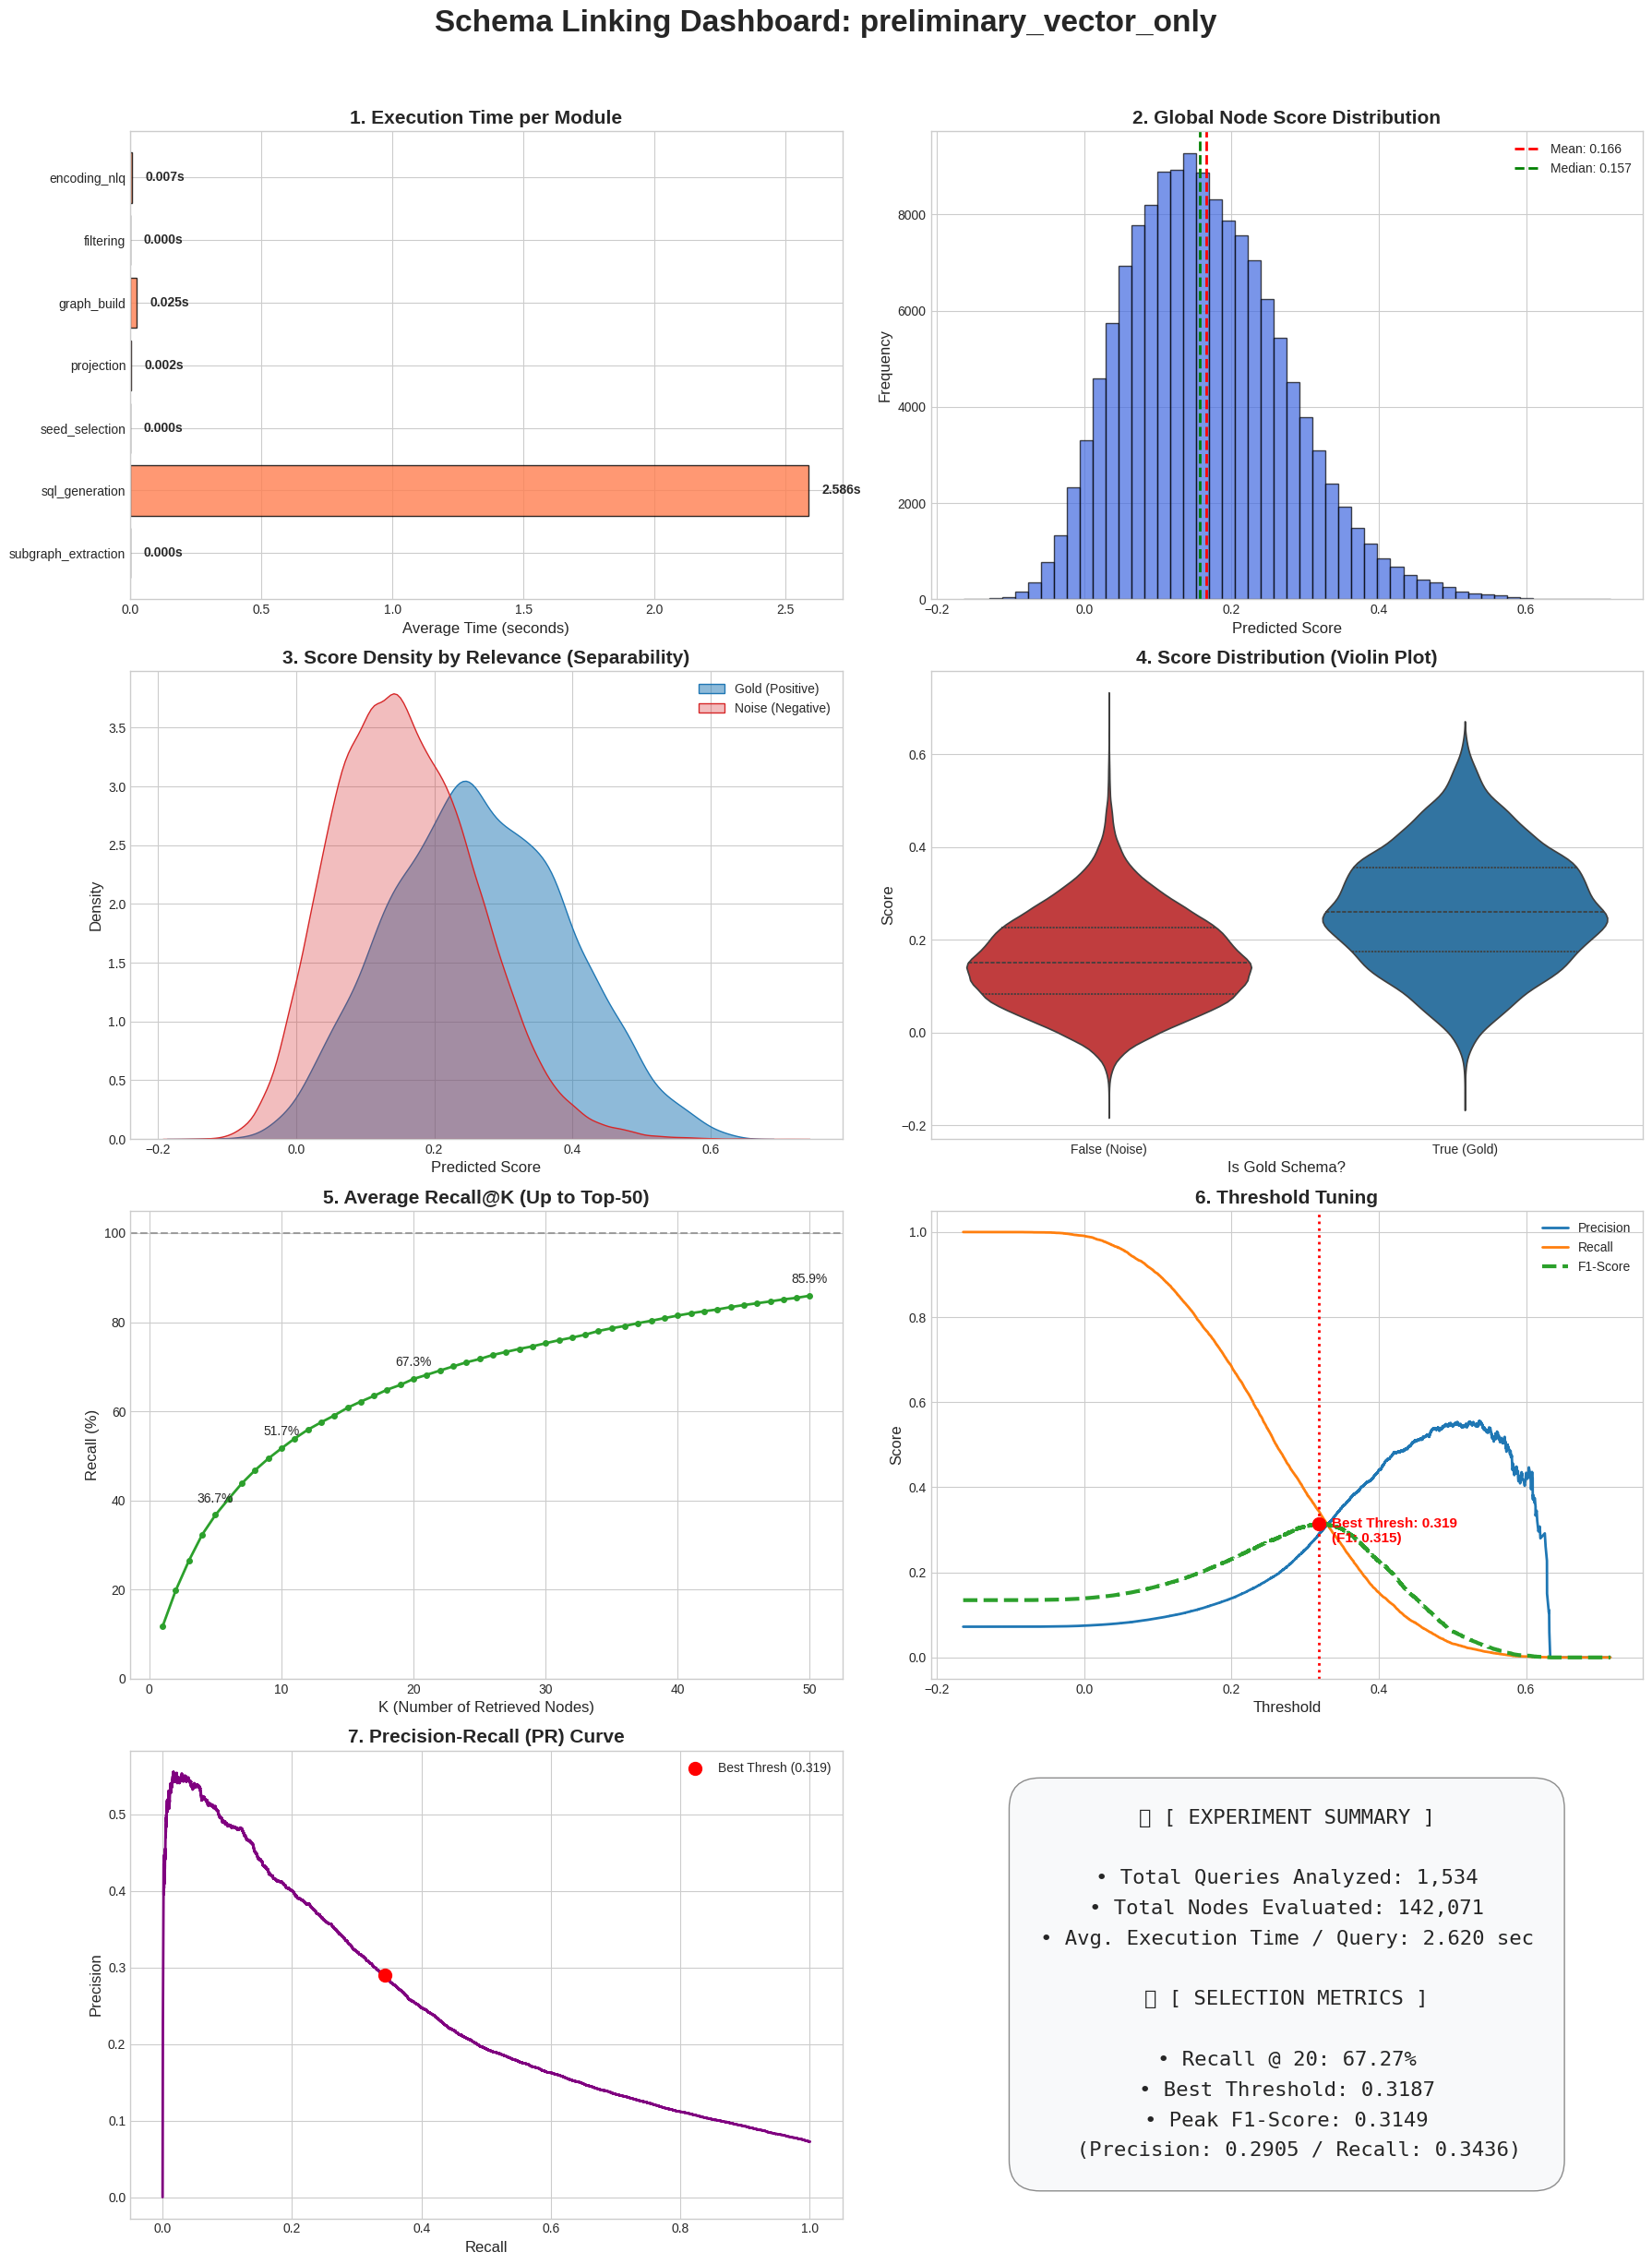

In [6]:
exp_name= "preliminary_vector_only"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 2. Preliminary: Graph Expansion

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_graph_expansion/score_analysis_preliminary_graph_expansion.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_graph_expansion/profiling_preliminary_graph_expansion.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

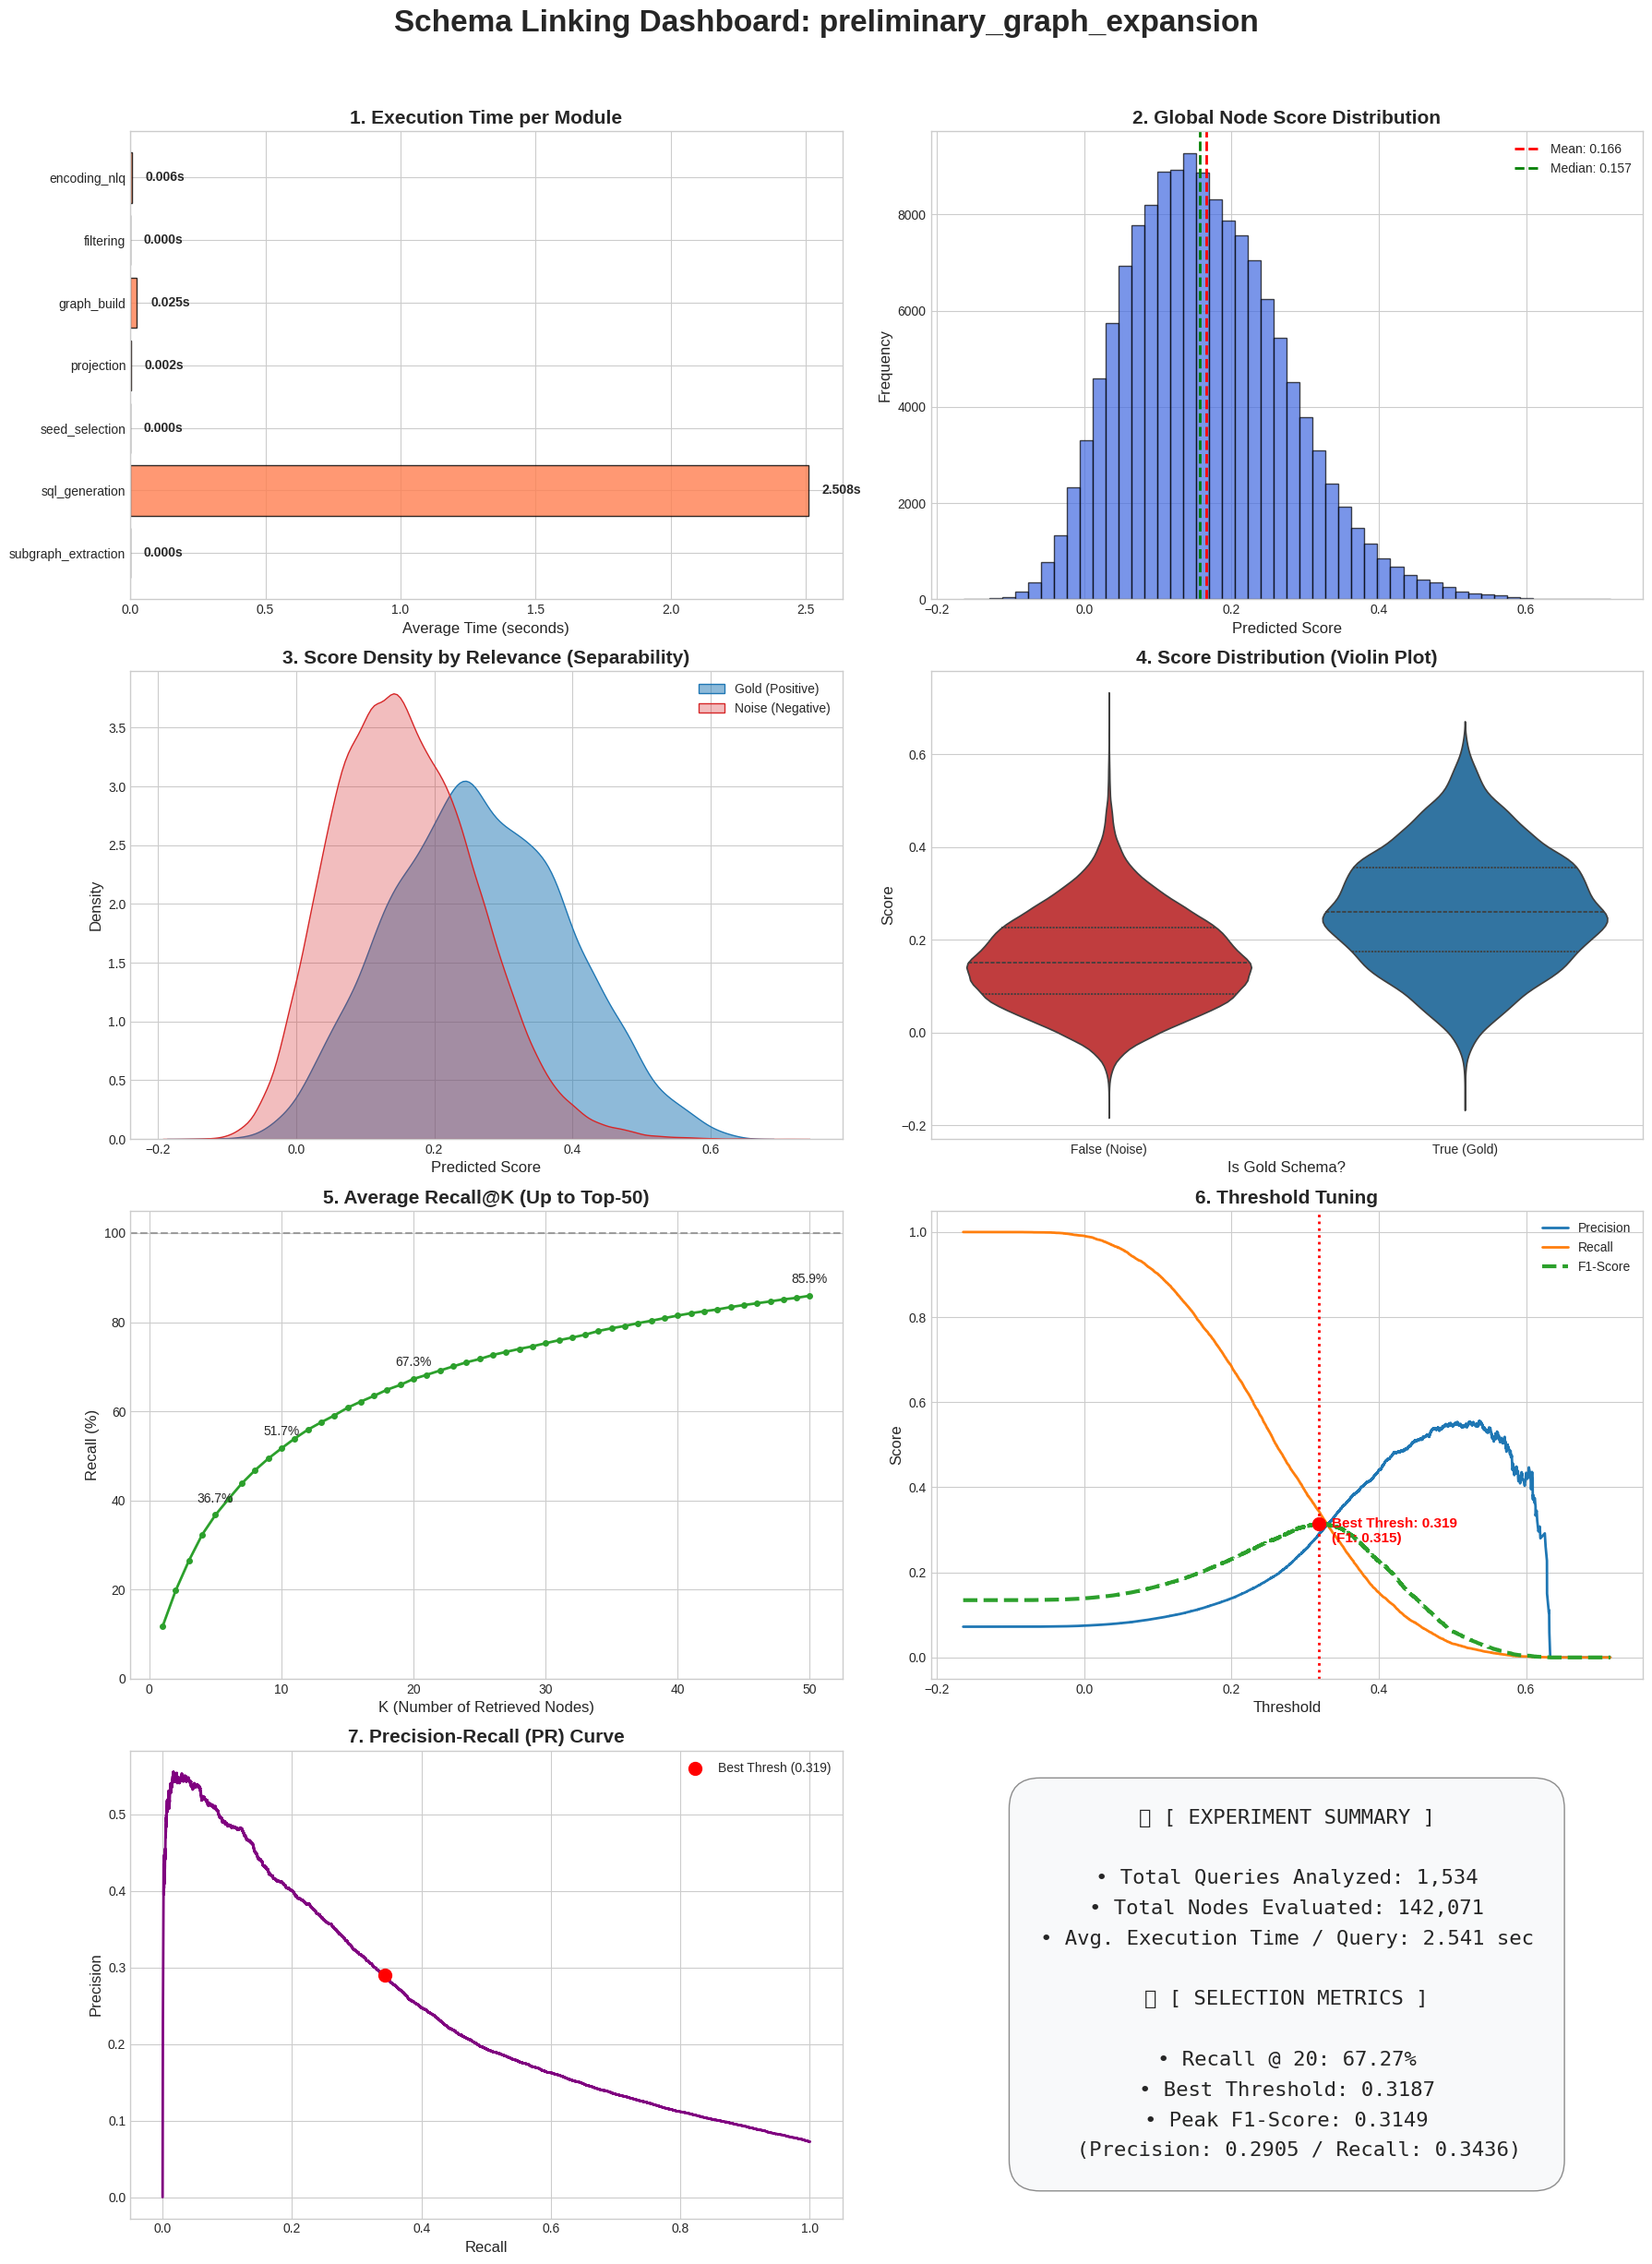

In [7]:
exp_name= "preliminary_graph_expansion"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 3. Preliminary: Agent Filtering

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_graph_and_agent/score_analysis_preliminary_graph_and_agent.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/preliminary_graph_and_agent/profiling_preliminary_graph_and_agent.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

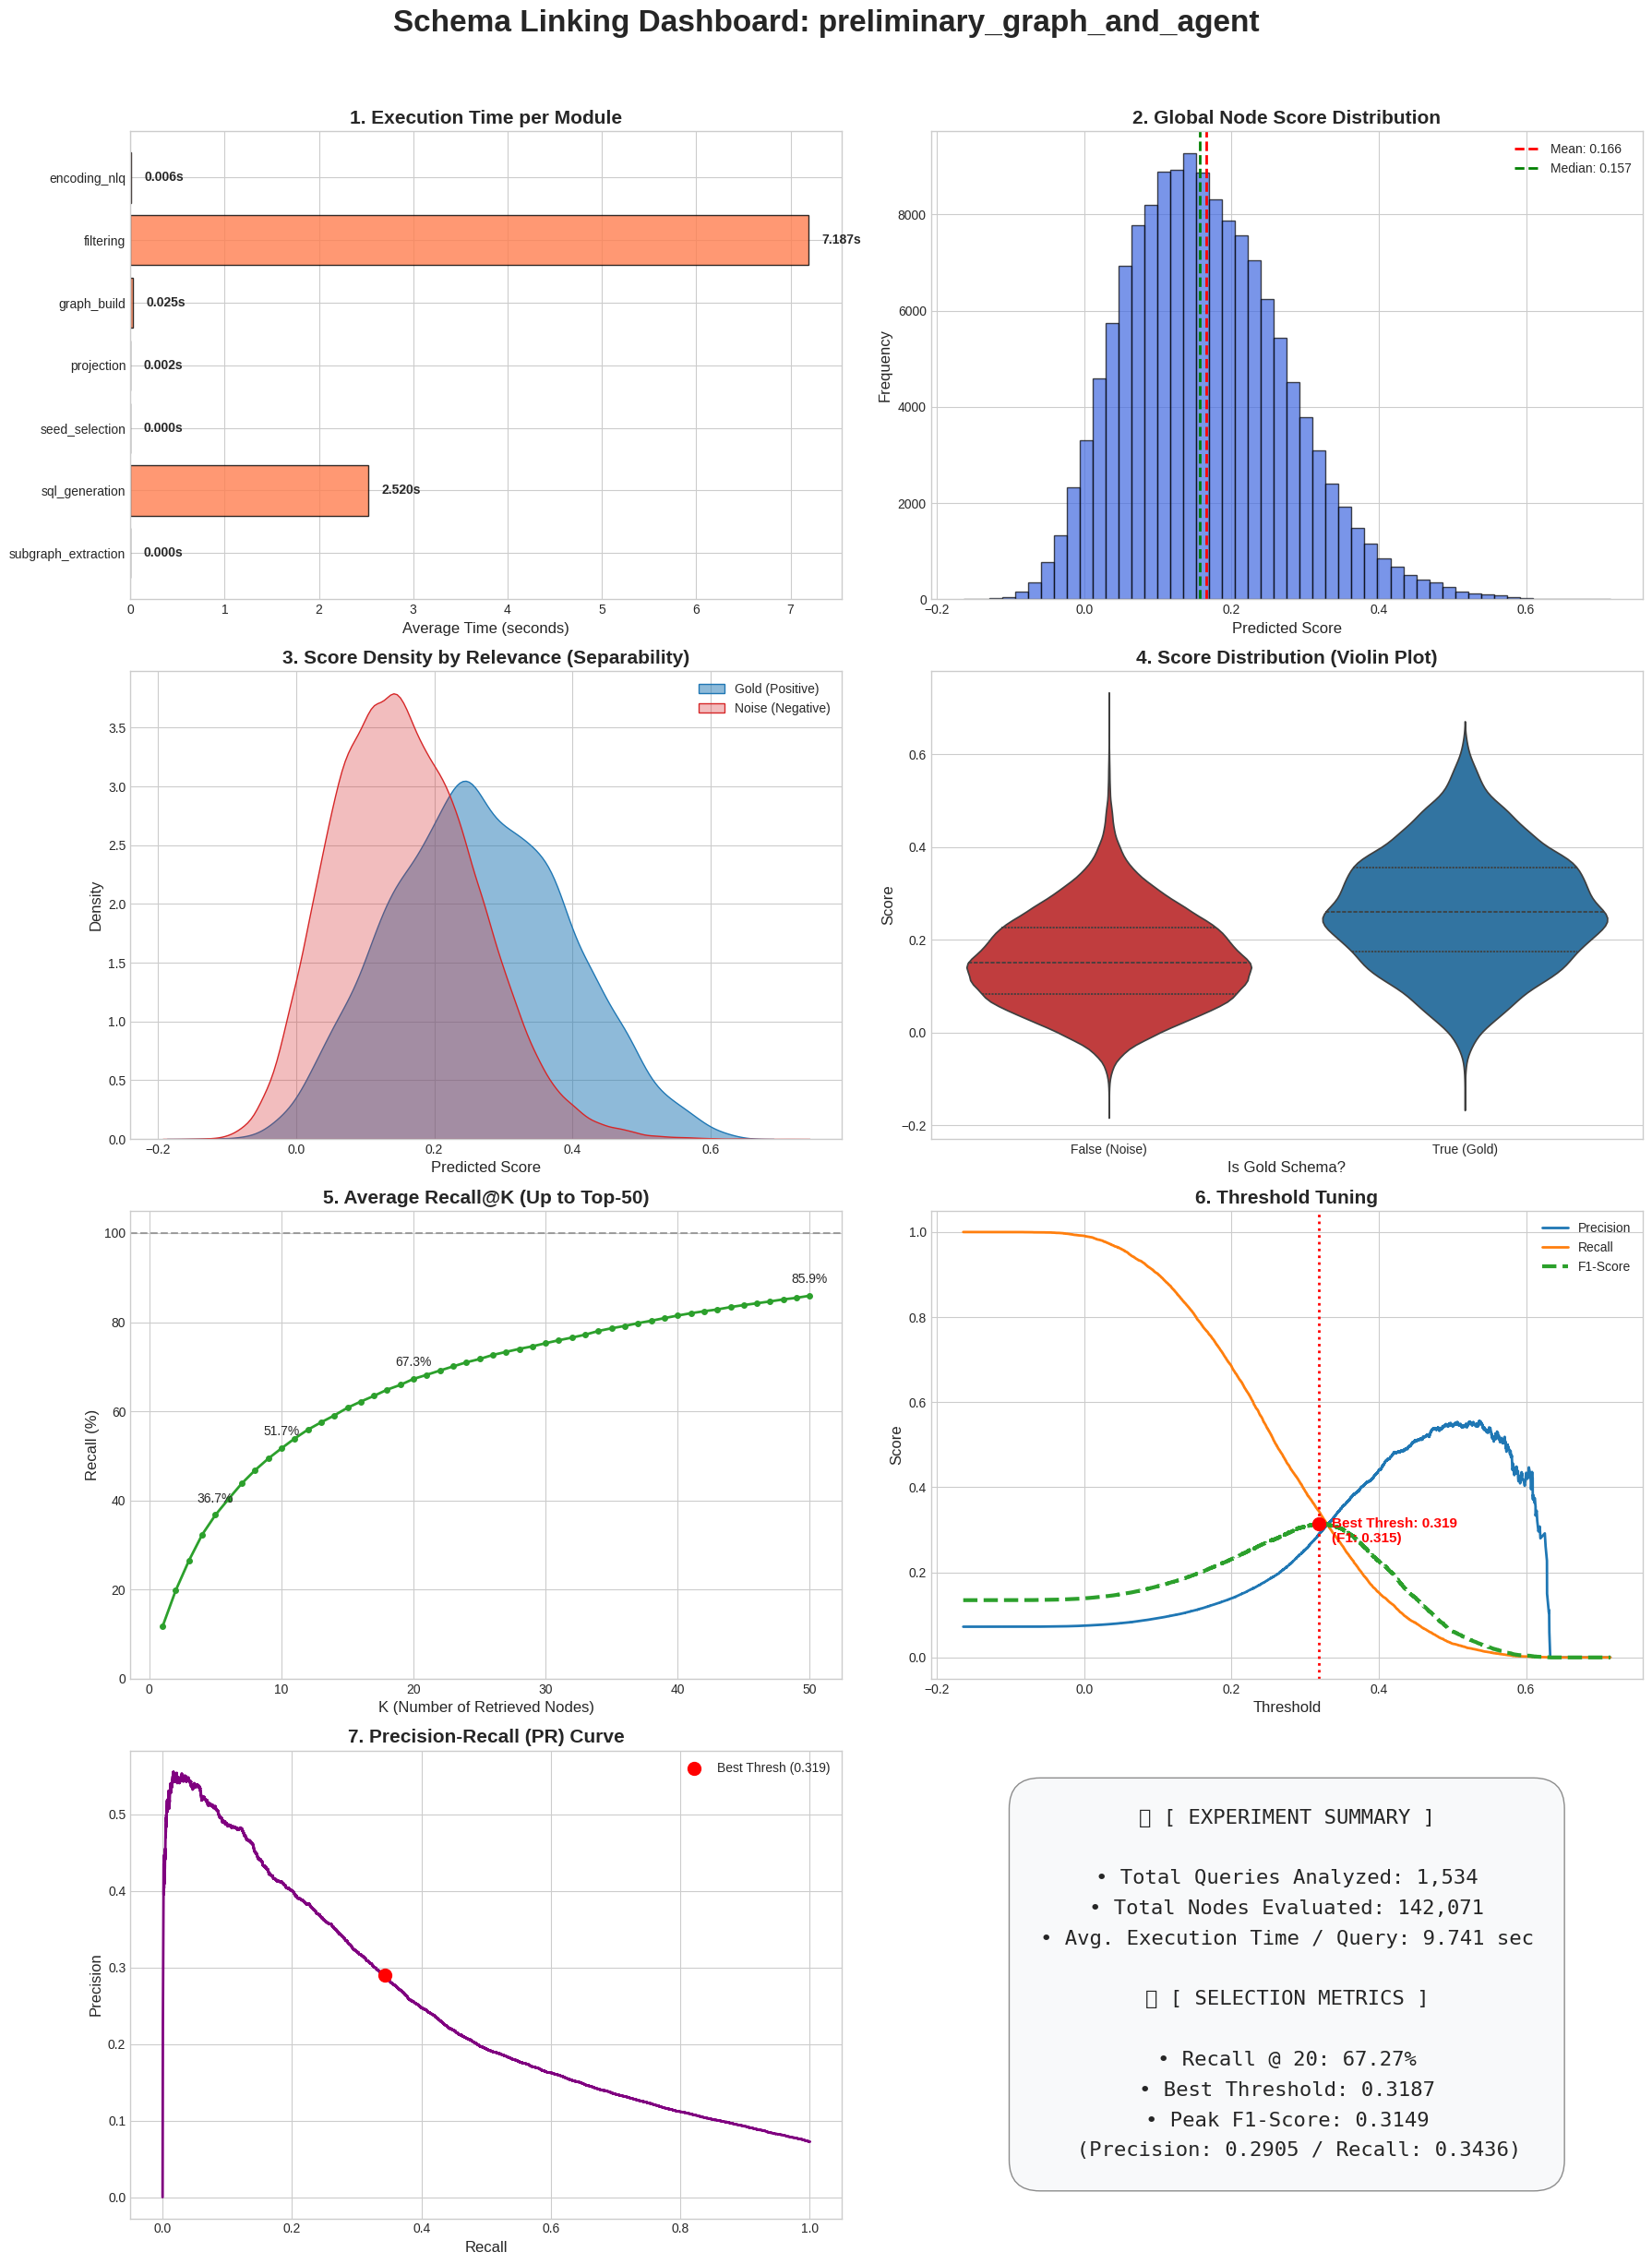

In [8]:
exp_name= "preliminary_graph_and_agent"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 4. Baseline: XiYanSQL Schema Filtering

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_xiyansql/score_analysis_baseline_xiyansql.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_xiyansql/profiling_baseline_xiyansql.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

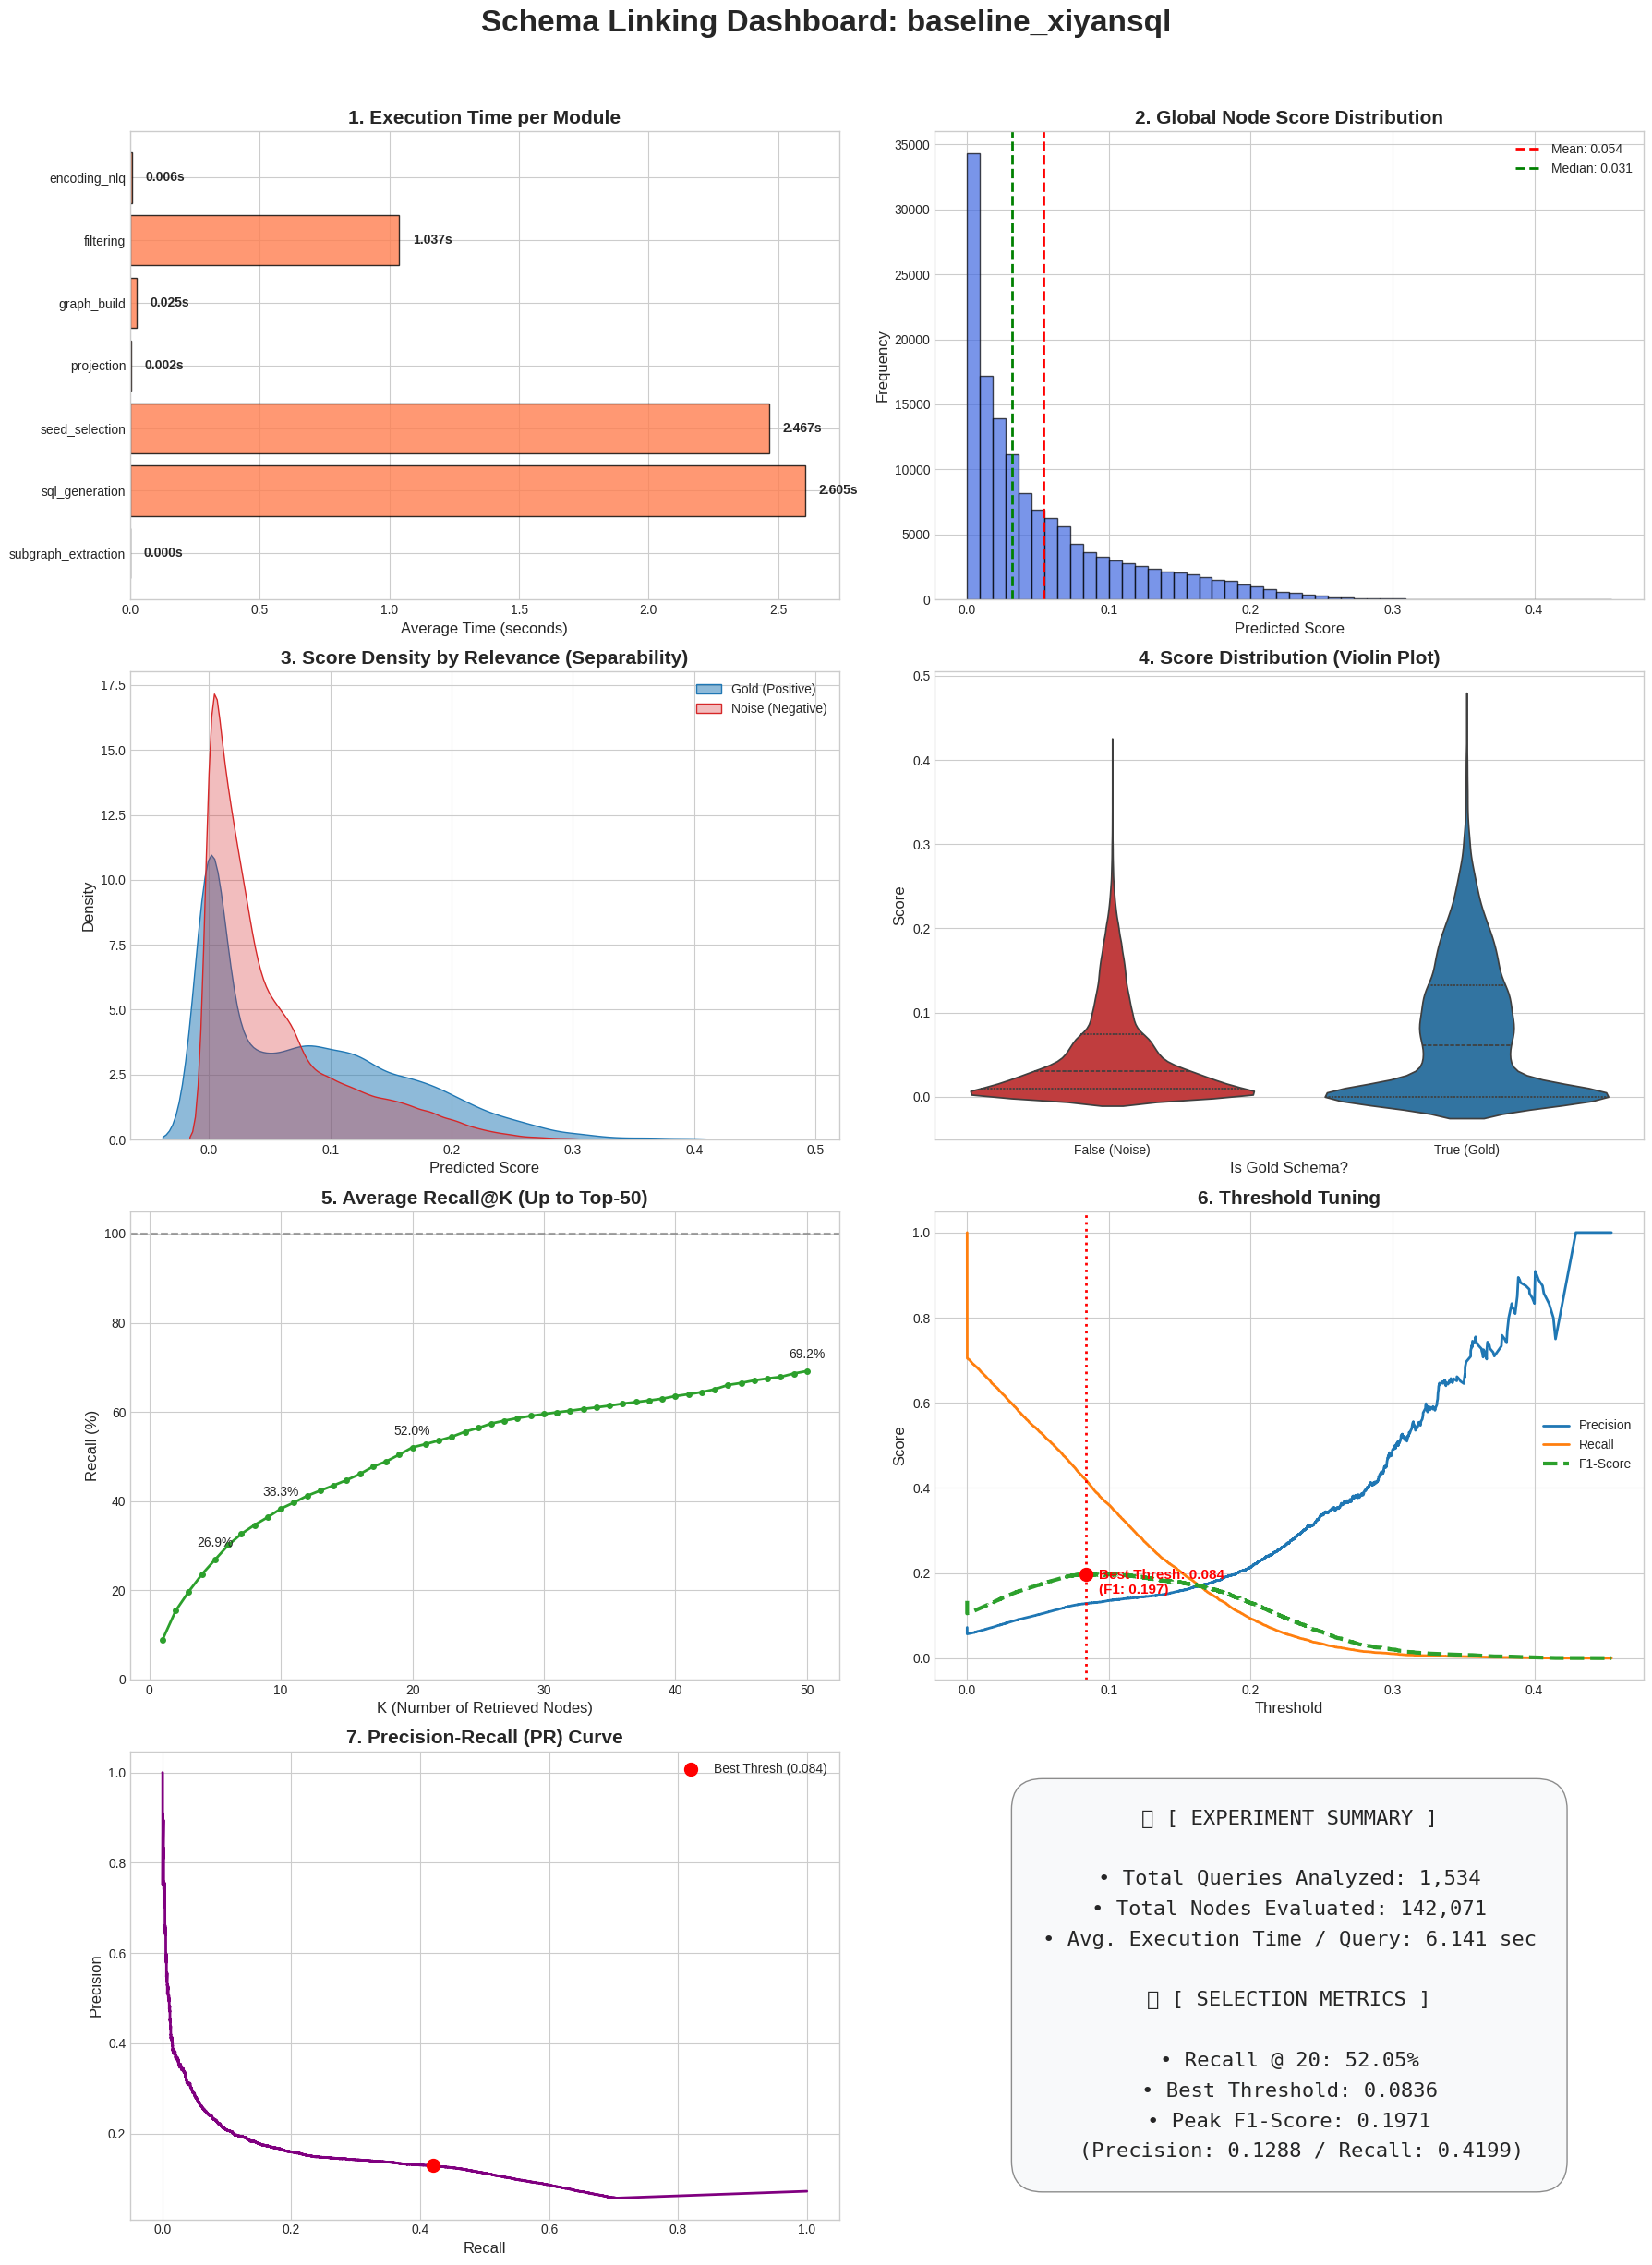

In [9]:
exp_name= "baseline_xiyansql"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 5. Baseline: G-Retriever

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_g_retriever/score_analysis_baseline_g_retriever.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_g_retriever/profiling_baseline_g_retriever.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

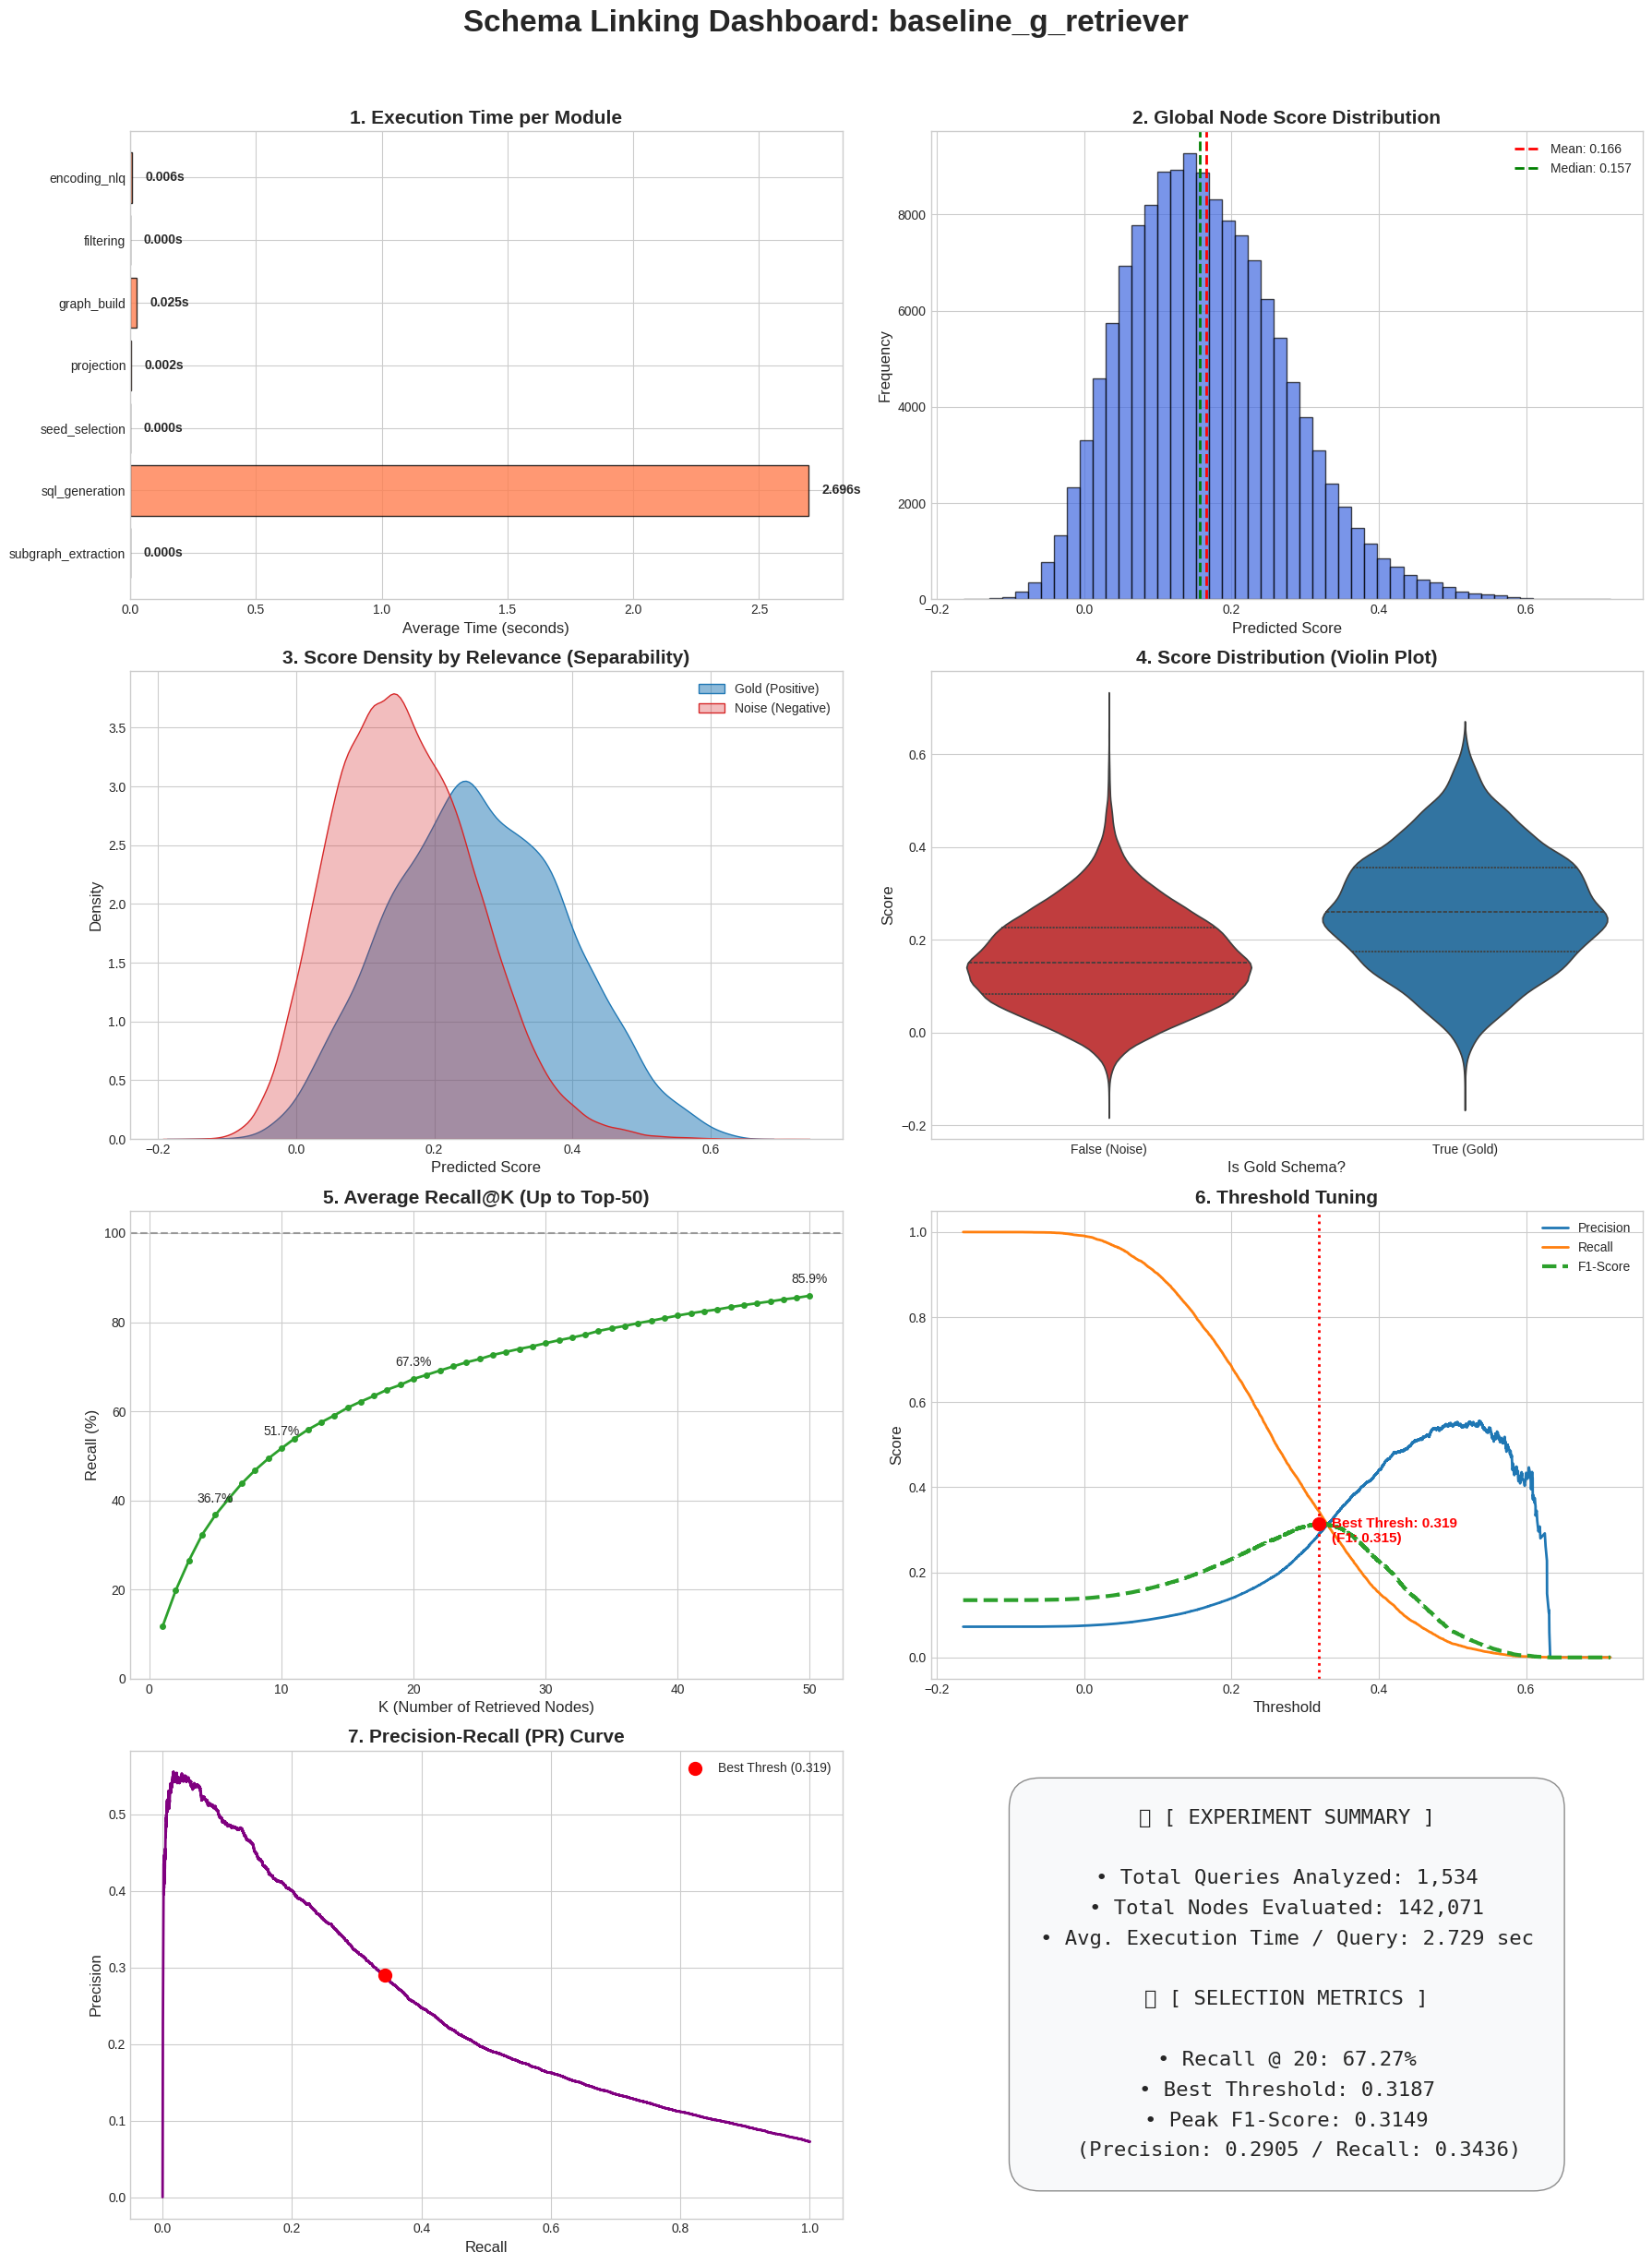

In [10]:
exp_name= "baseline_g_retriever"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 6. Baseline: LinkAlign

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_linkalign/score_analysis_baseline_linkalign.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/baselines/baseline_linkalign/profiling_baseline_linkalign.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

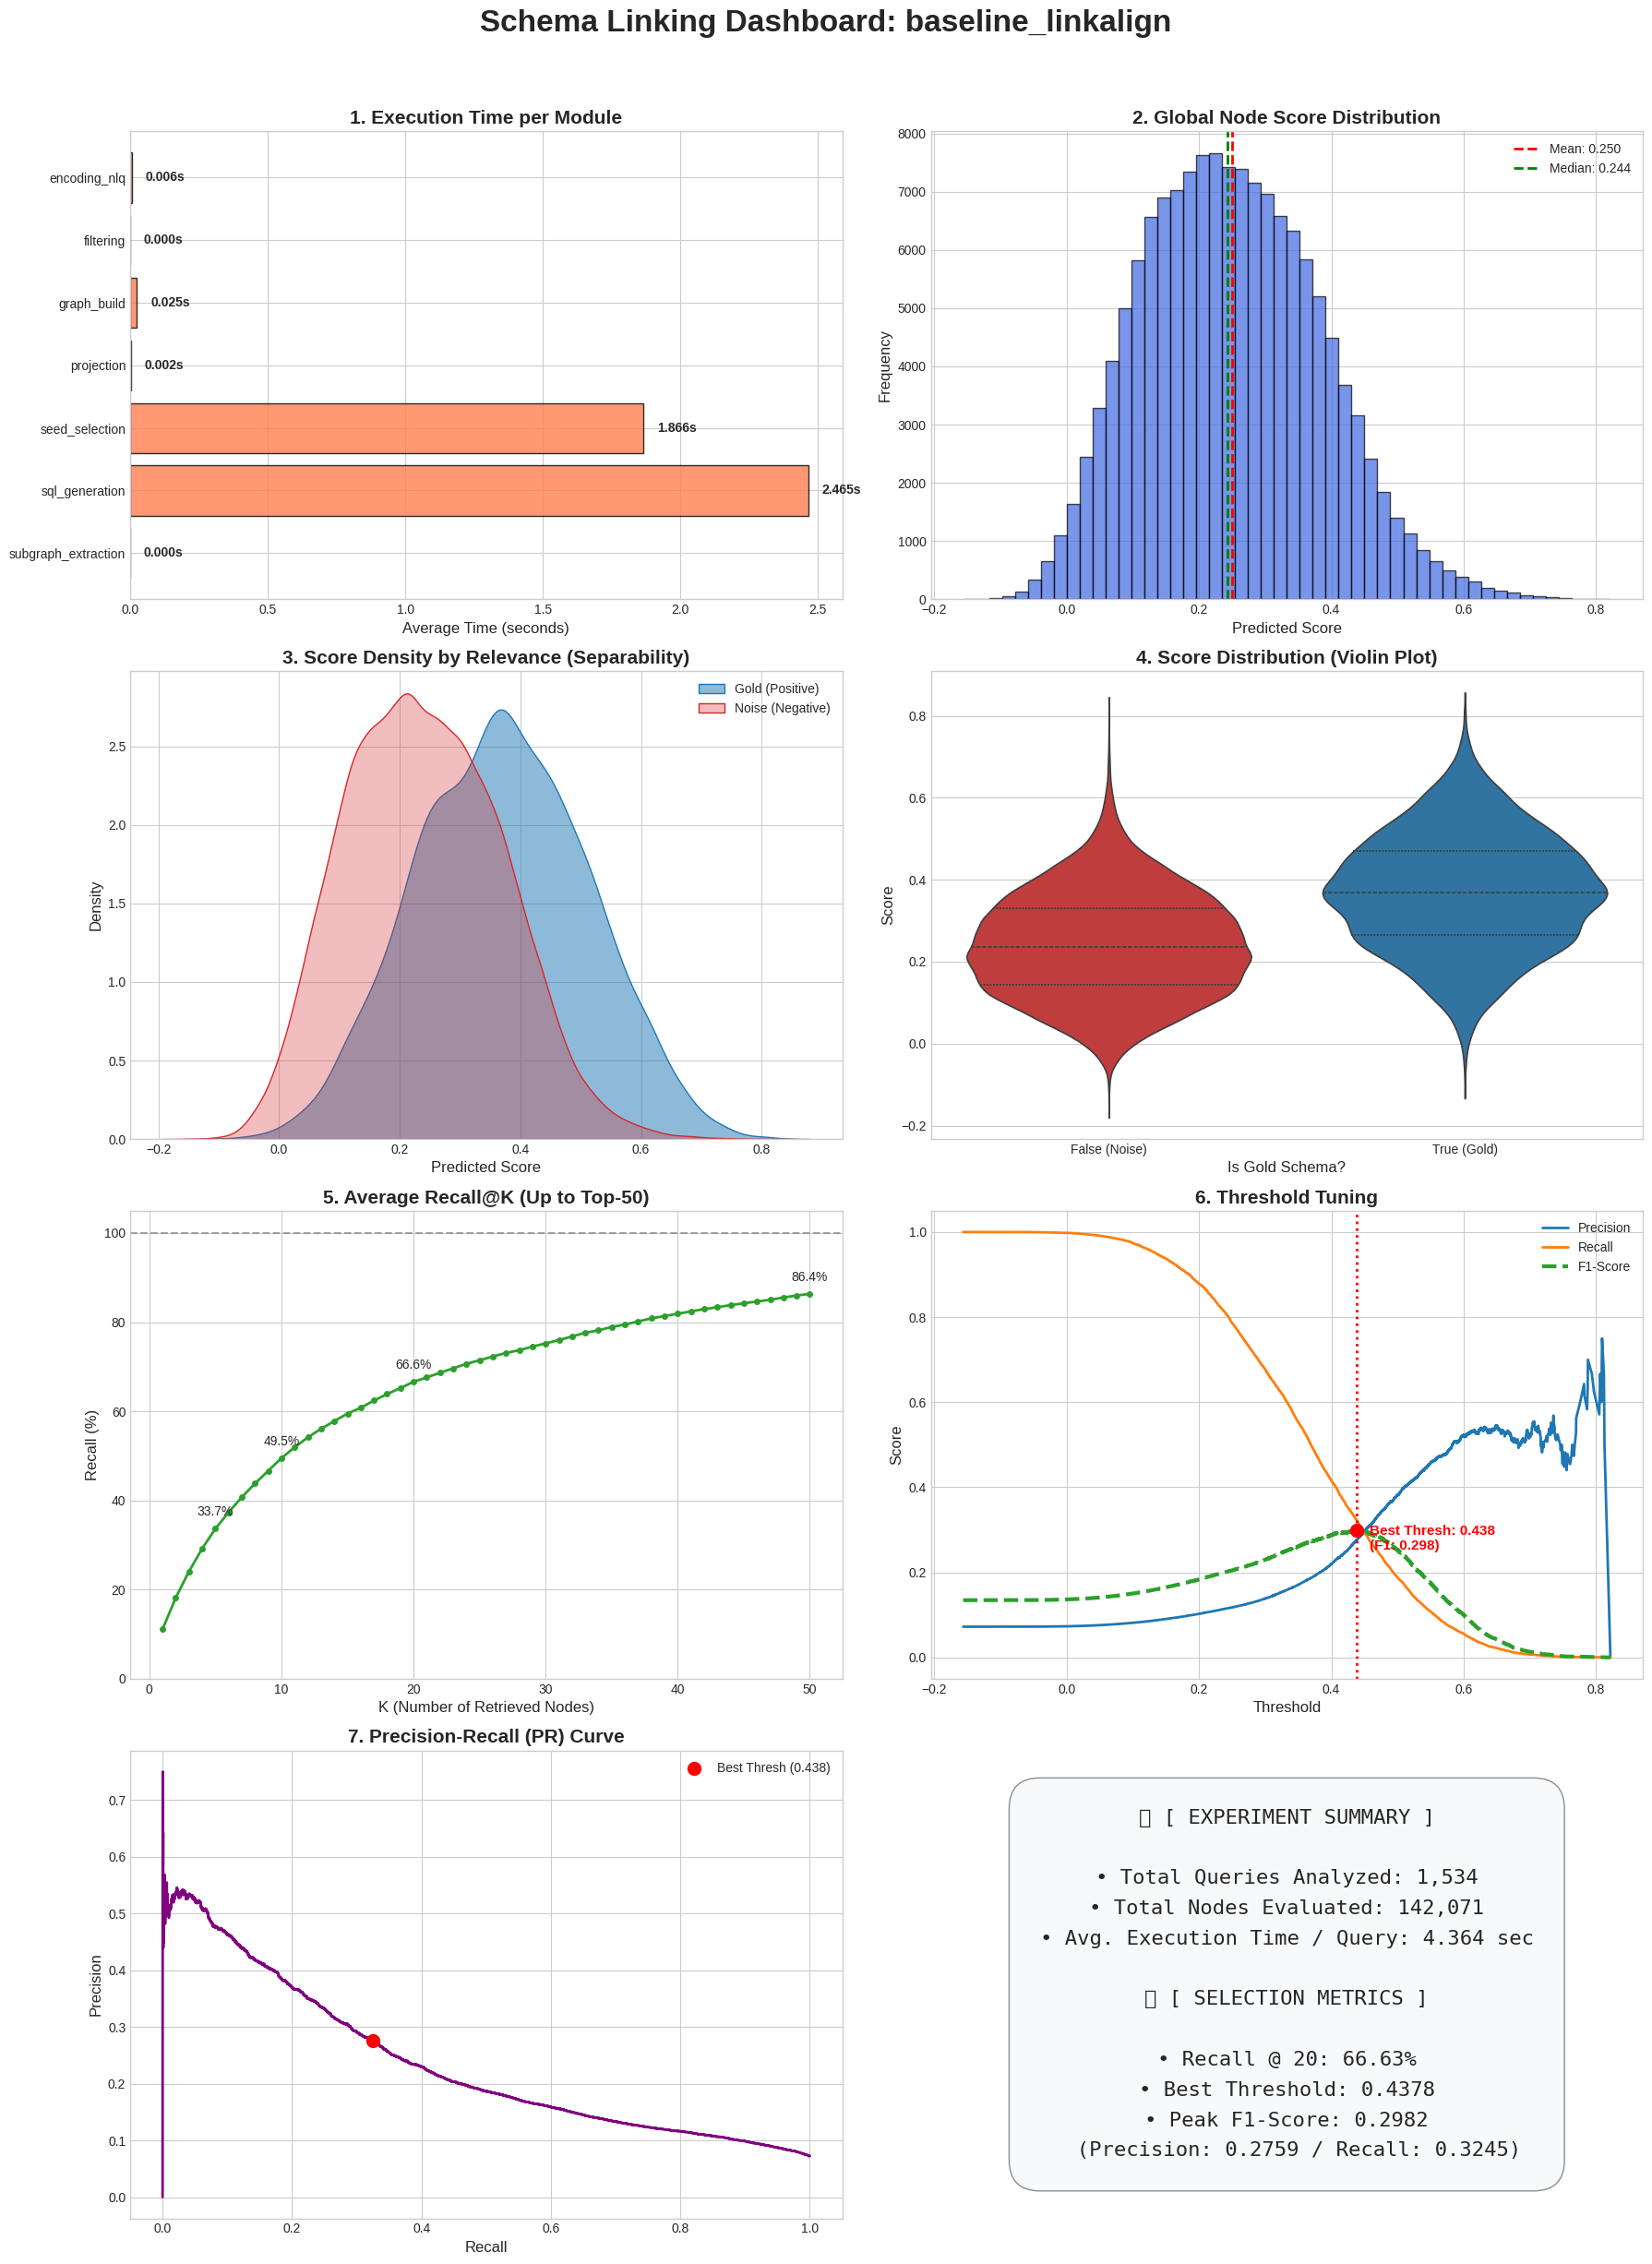

In [11]:
exp_name= "baseline_linkalign"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/baselines/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 7. Experiment: GAT with Classifier

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/experiments/experiment_gat_classifier/score_analysis_experiment_gat_classifier.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/experiments/experiment_gat_classifier/profiling_experiment_gat_classifier.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

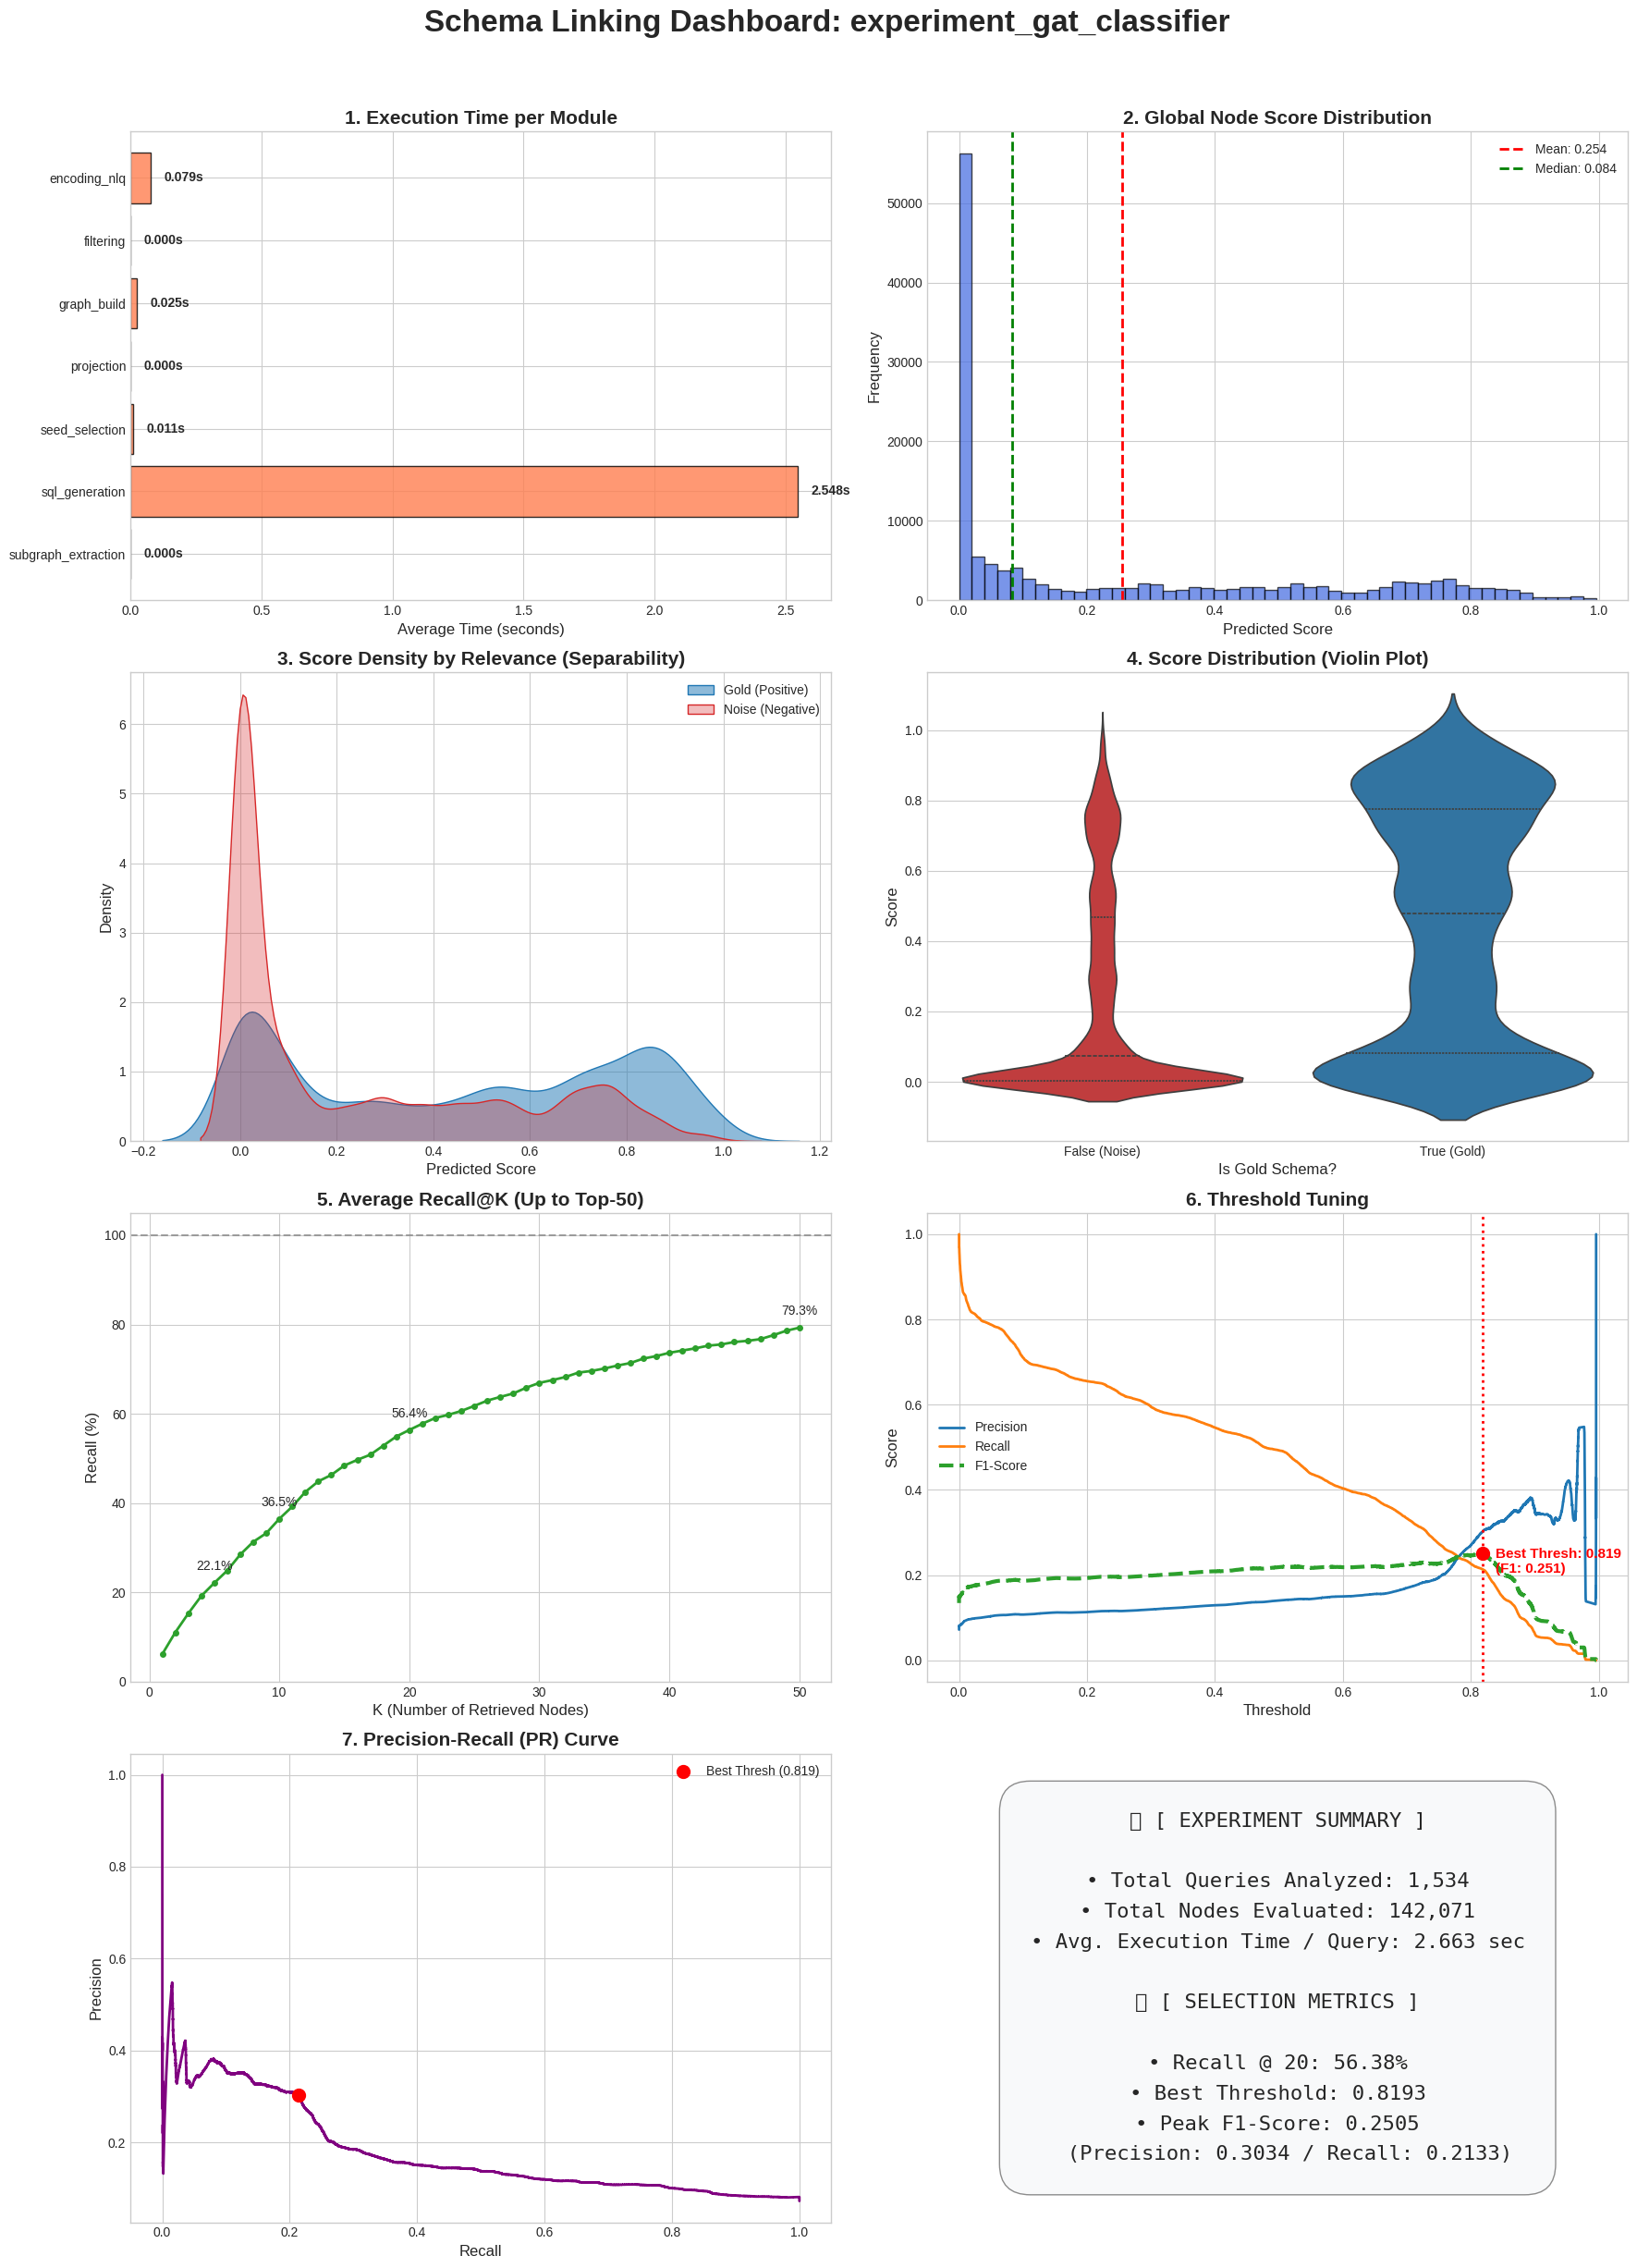

In [12]:
exp_name= "experiment_gat_classifier"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/experiments/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/experiments/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)

# 8. Experiments: GAT Multi Agent

🔍 Loading Score data from /home/hyeonjin/thesis_refactored/outputs/experiments/experiment_gat_pcst_multi_agent/score_analysis_experiment_gat_pcst_multi_agent.jsonl...
🔍 Loading Profiling data from /home/hyeonjin/thesis_refactored/outputs/experiments/experiment_gat_pcst_multi_agent/profiling_experiment_gat_pcst_multi_agent.jsonl...


/tmp/ipykernel_2941636/3491862366.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_gold', y='score', palette={True: '#1f77b4', False: '#d62728', 'True': '#1f77b4', 'False': '#d62728'}, inner='quartile', ax=axes[1, 1])
/tmp/ipykernel_2941636/3491862366.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['False (Noise)', 'True (Gold)'])
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2941636/3491862366.py:155: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/hyeonjin/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

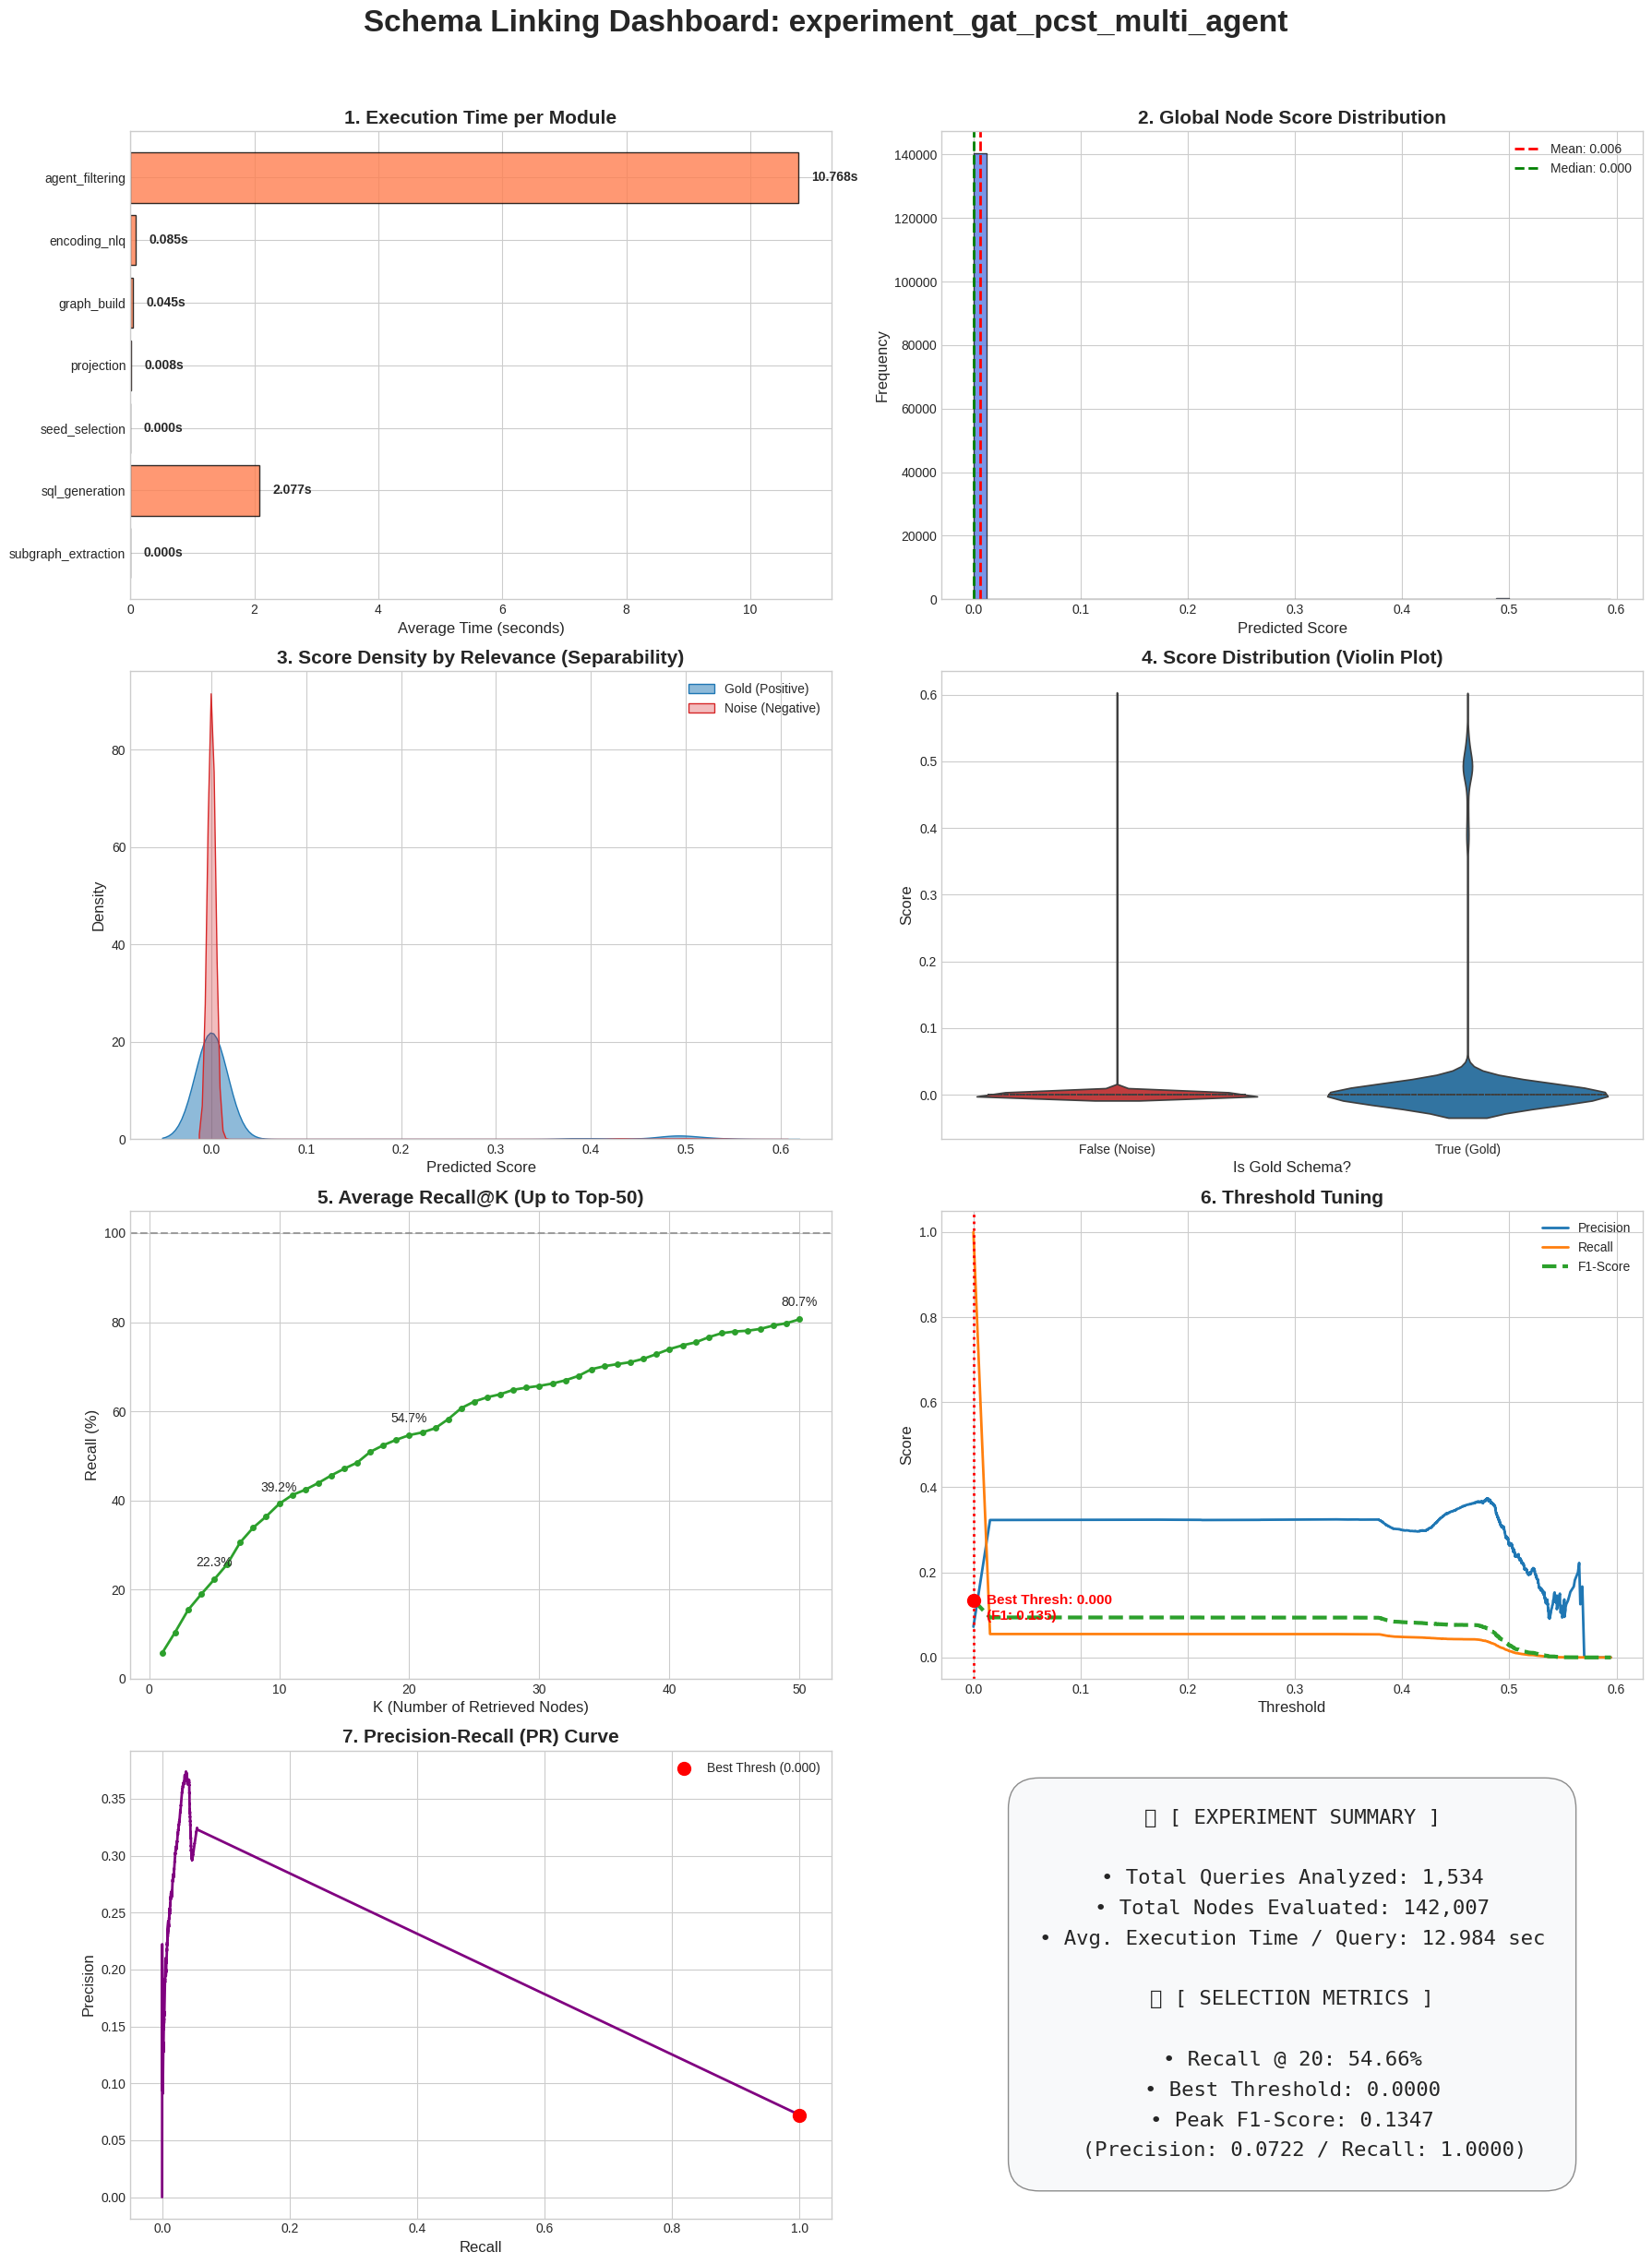

In [13]:
exp_name= "experiment_gat_pcst_multi_agent"
score_json_path = f"/home/hyeonjin/thesis_refactored/outputs/experiments/{exp_name}/score_analysis_{exp_name}.jsonl"
profiling_json_path = f"/home/hyeonjin/thesis_refactored/outputs/experiments/{exp_name}/profiling_{exp_name}.jsonl"
max_k = 50

plot_dashboard(score_json_path, profiling_json_path, exp_name, max_k)